In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [2]:
# 데이터 불러오기
df = pd.read_csv('DieCasting_Quality_Raw_Data.csv',header=[0,1])

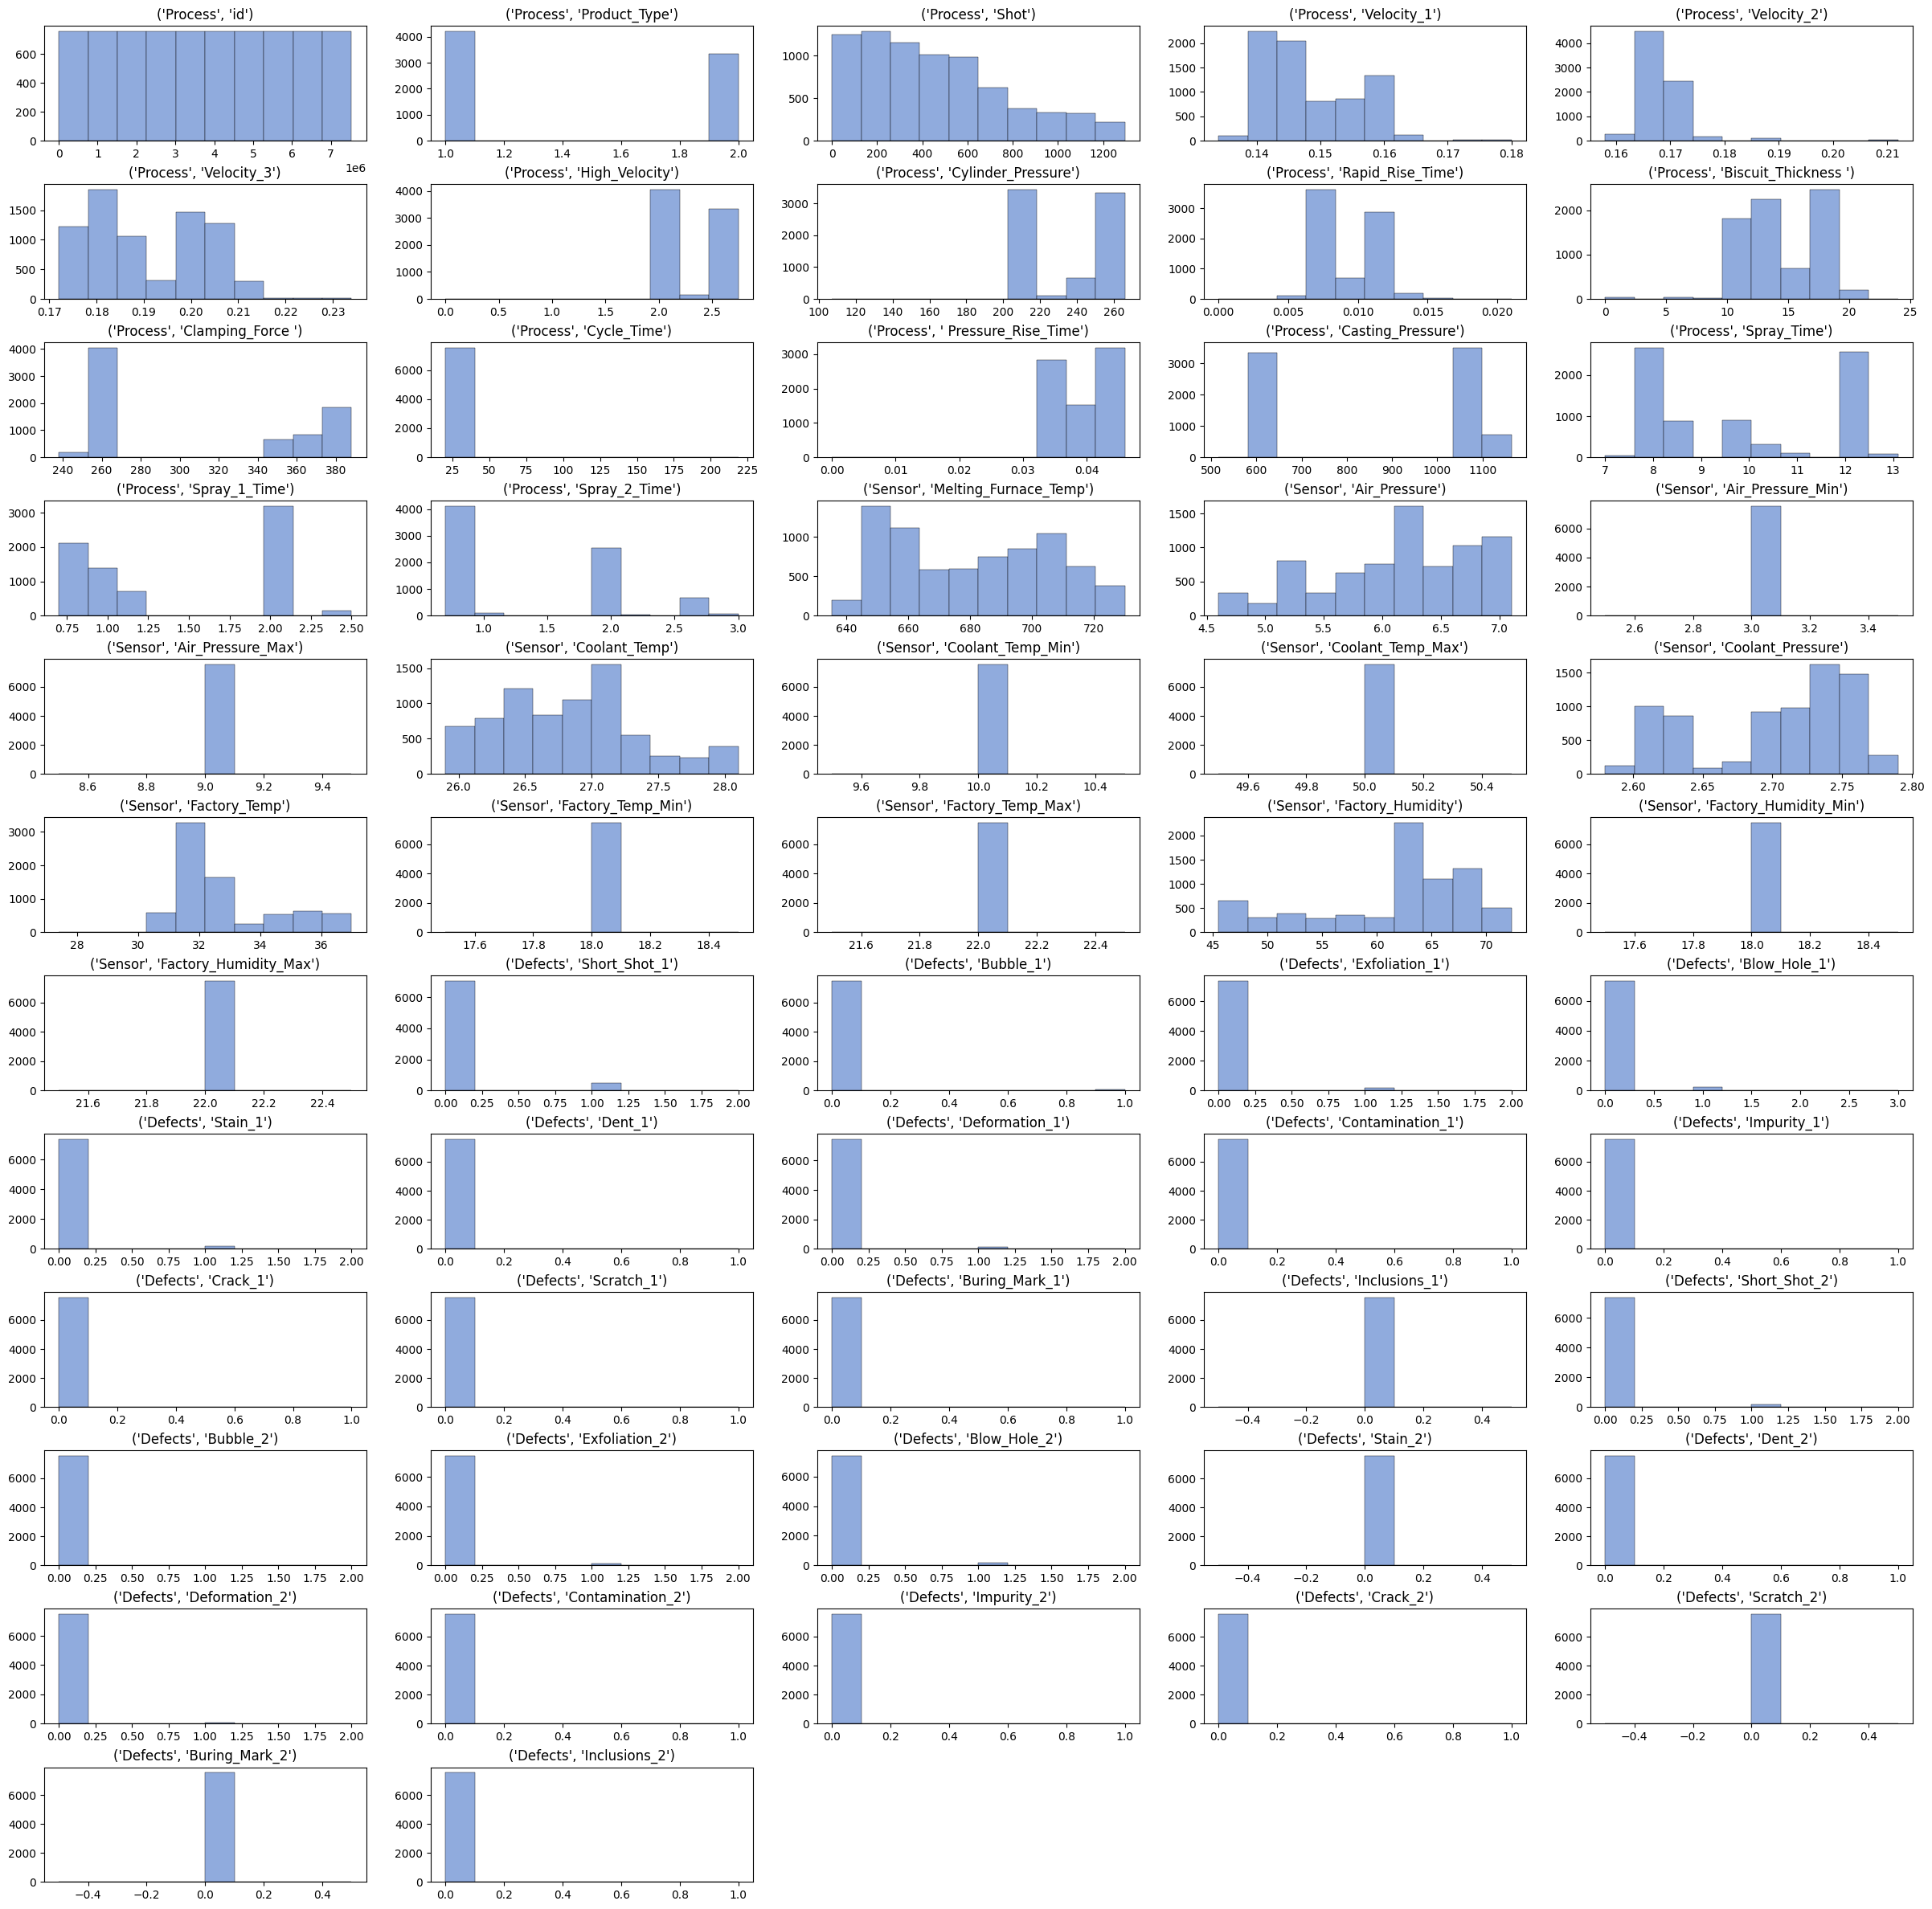

In [3]:
# 히스토그램을 통한 변수별 데이터 파악 (Given)
plt.figure(figsize = (30,30))
plt.subplots_adjust(hspace = 0.38) #그림 간격 조절

# 각 변수의 막대그래프 개수
for index,value in enumerate(df):
    sub = plt.subplot(12,5,index + 1)
    sub.hist(df[value],color = (144/255,171/255,221/255), linewidth = .3,edgecolor = 'black')
    
    plt.title(value)

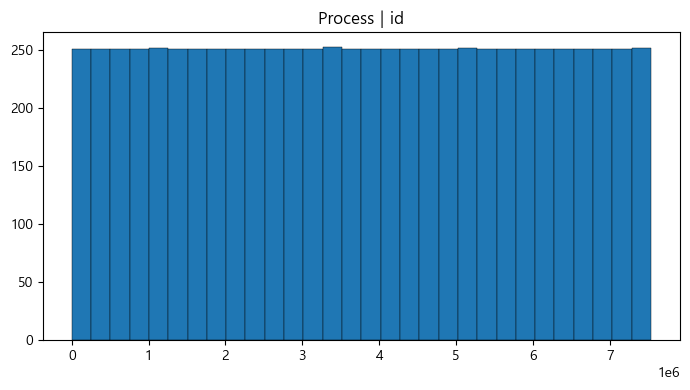

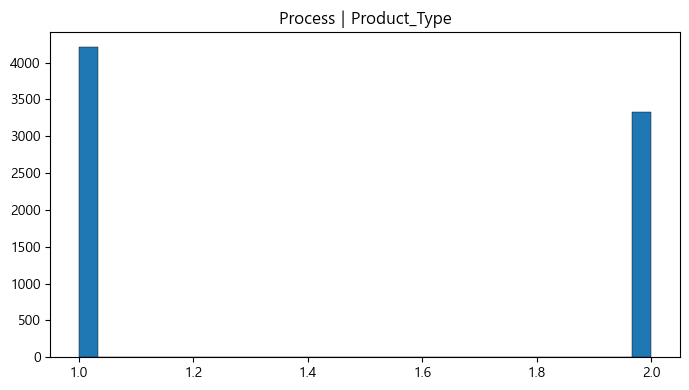

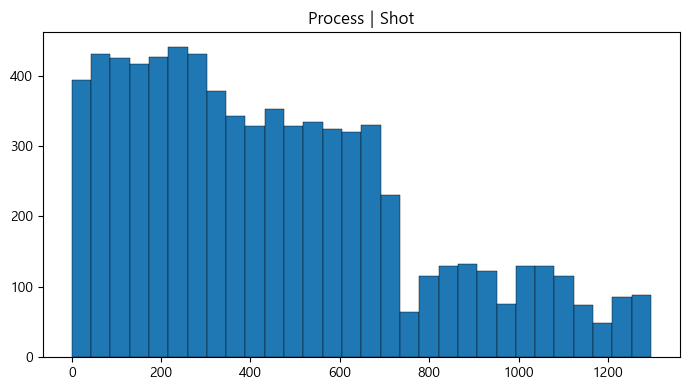

[Process] 히스토그램 저장 완료: 17개 (min/max 컬럼 제외). 저장 폴더: eda_plots/hist/process


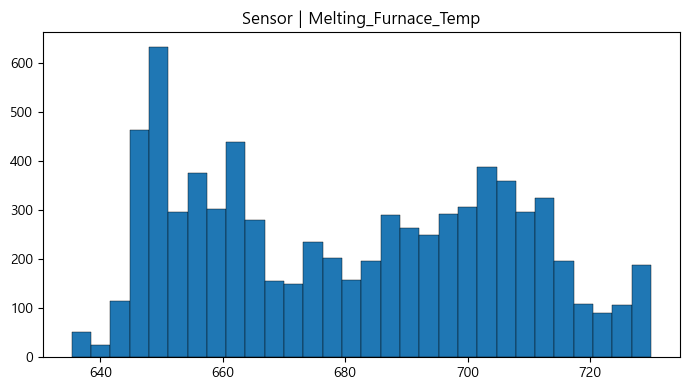

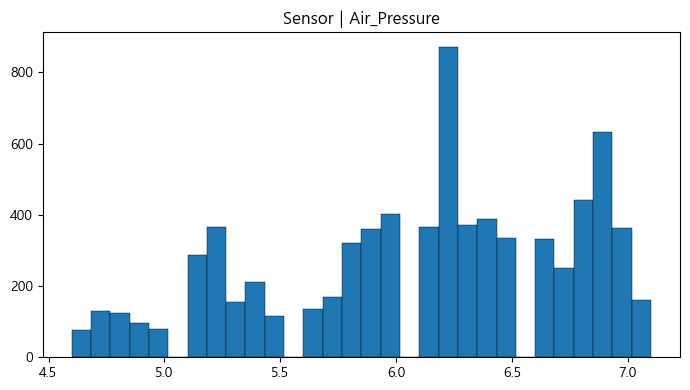

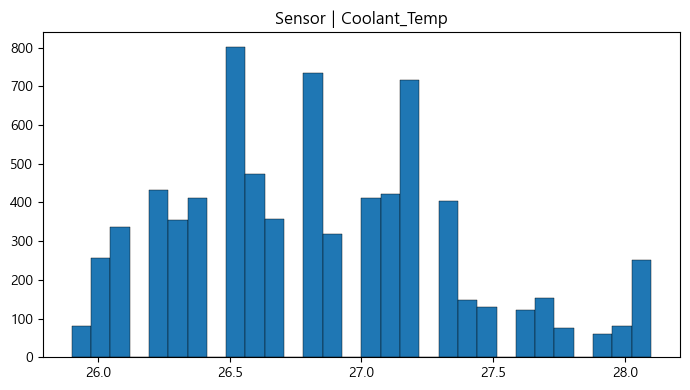

[Sensor] 히스토그램 저장 완료: 6개 (min/max 컬럼 제외). 저장 폴더: eda_plots/hist/sensor


In [8]:
# (수정) Process / Sensor 변수 "각 컬럼당 1장" 히스토그램 저장 (+ min/max 컬럼 제외)
# - 너무 많은 플롯 출력으로 노트북이 무거워지는 것을 방지하기 위해,
#   기본은 "파일 저장" 중심으로 수행하고, 미리보기는 일부(show_n)만 출력합니다.

import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = "Malgun Gothic"   # 맑은 고딕
mpl.rcParams["axes.unicode_minus"] = False      # 마이너스(-) 깨짐 방지


def _get_group_df(_df: pd.DataFrame, group: str) -> pd.DataFrame:
    """
    MultiIndex 컬럼: ('Process','Velocity_1') 형태를 우선 가정.
    flat 컬럼인 경우에도 group 이름이 포함된 컬럼명을 최대한 찾아 반환합니다.
    """
    if isinstance(_df.columns, pd.MultiIndex):
        # 1레벨이 그룹명인 경우
        if group in _df.columns.get_level_values(0):
            return _df[group].copy()

        # 레벨명이 다르거나 구조가 다른 경우: "group" 문자열 포함으로 탐색
        cols = [c for c in _df.columns if group.lower() in str(c[0]).lower() or group.lower() in str(c[1]).lower()]
        if len(cols) == 0:
            raise KeyError(f"{group} 그룹 컬럼을 찾지 못했습니다. (MultiIndex)")
        return _df[cols].copy()

    # flat 컬럼
    cols = [c for c in _df.columns if group.lower() in str(c).lower()]
    if len(cols) == 0:
        raise KeyError(f"{group} 그룹 컬럼을 찾지 못했습니다. (flat columns)")
    return _df[cols].copy()


def _is_minmax_col(col_name: str) -> bool:
    """
    min/max 값 컬럼 제외 규칙
    - 예: *_min, *_max, 'min', 'max', '... min ...', '... max ...' 등
    """
    s = str(col_name).strip().lower()
    if s in {"min", "max"}:
        return True
    # _min / _max 또는 공백/언더스코어 경계의 min/max
    return bool(re.search(r'(^|[_\s])(min|max)($|[_\s])', s))


def _safe_filename(name: str) -> str:
    # 파일명에 사용 불가 문자 제거
    return re.sub(r'[\\/:*?"<>| ]+', "_", str(name)).strip("_")


def _to_numeric_series(s: pd.Series) -> pd.Series:
    s2 = pd.to_numeric(s, errors="coerce")
    return s2


def save_hist_per_column(df_grp: pd.DataFrame, group_name: str, out_dir: str, bins: int = 30, show_n: int = 3) -> None:
    os.makedirs(out_dir, exist_ok=True)

    # min/max 컬럼 제외
    cols_use = []
    for c in df_grp.columns:
        col_label = c  # df_grp는 보통 1-level 컬럼(이미 group만 슬라이스)
        if not _is_minmax_col(col_label):
            cols_use.append(c)

    saved = 0
    shown = 0

    for c in cols_use:
        col_label = str(c)
        safe = _safe_filename(col_label)
        save_path = os.path.join(out_dir, f"{safe}.png")

        x = _to_numeric_series(df_grp[c]).dropna()
        if x.empty:
            continue

        plt.figure(figsize=(7, 4))
        plt.hist(x, bins=bins, linewidth=0.3, edgecolor="black")
        plt.title(f"{group_name} | {col_label}")
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches="tight", dpi=200)

        saved += 1

        # 미리보기(일부만) 출력
        if shown < show_n:
            plt.show()
            shown += 1
        else:
            plt.close()

    print(f"[{group_name}] 히스토그램 저장 완료: {saved}개 (min/max 컬럼 제외). 저장 폴더: {out_dir}")


# 그룹 분리 (Process / Sensor)
df_process = _get_group_df(df, "Process")
df_sensor  = _get_group_df(df, "Sensor")

# Process: 컬럼당 1장 저장
save_hist_per_column(df_process, "Process", out_dir="eda_plots/hist/process", bins=30, show_n=3)

# Sensor: 컬럼당 1장 저장
save_hist_per_column(df_sensor,  "Sensor",  out_dir="eda_plots/hist/sensor",  bins=30, show_n=3)


<Axes: xlabel='None-None', ylabel='None-None'>

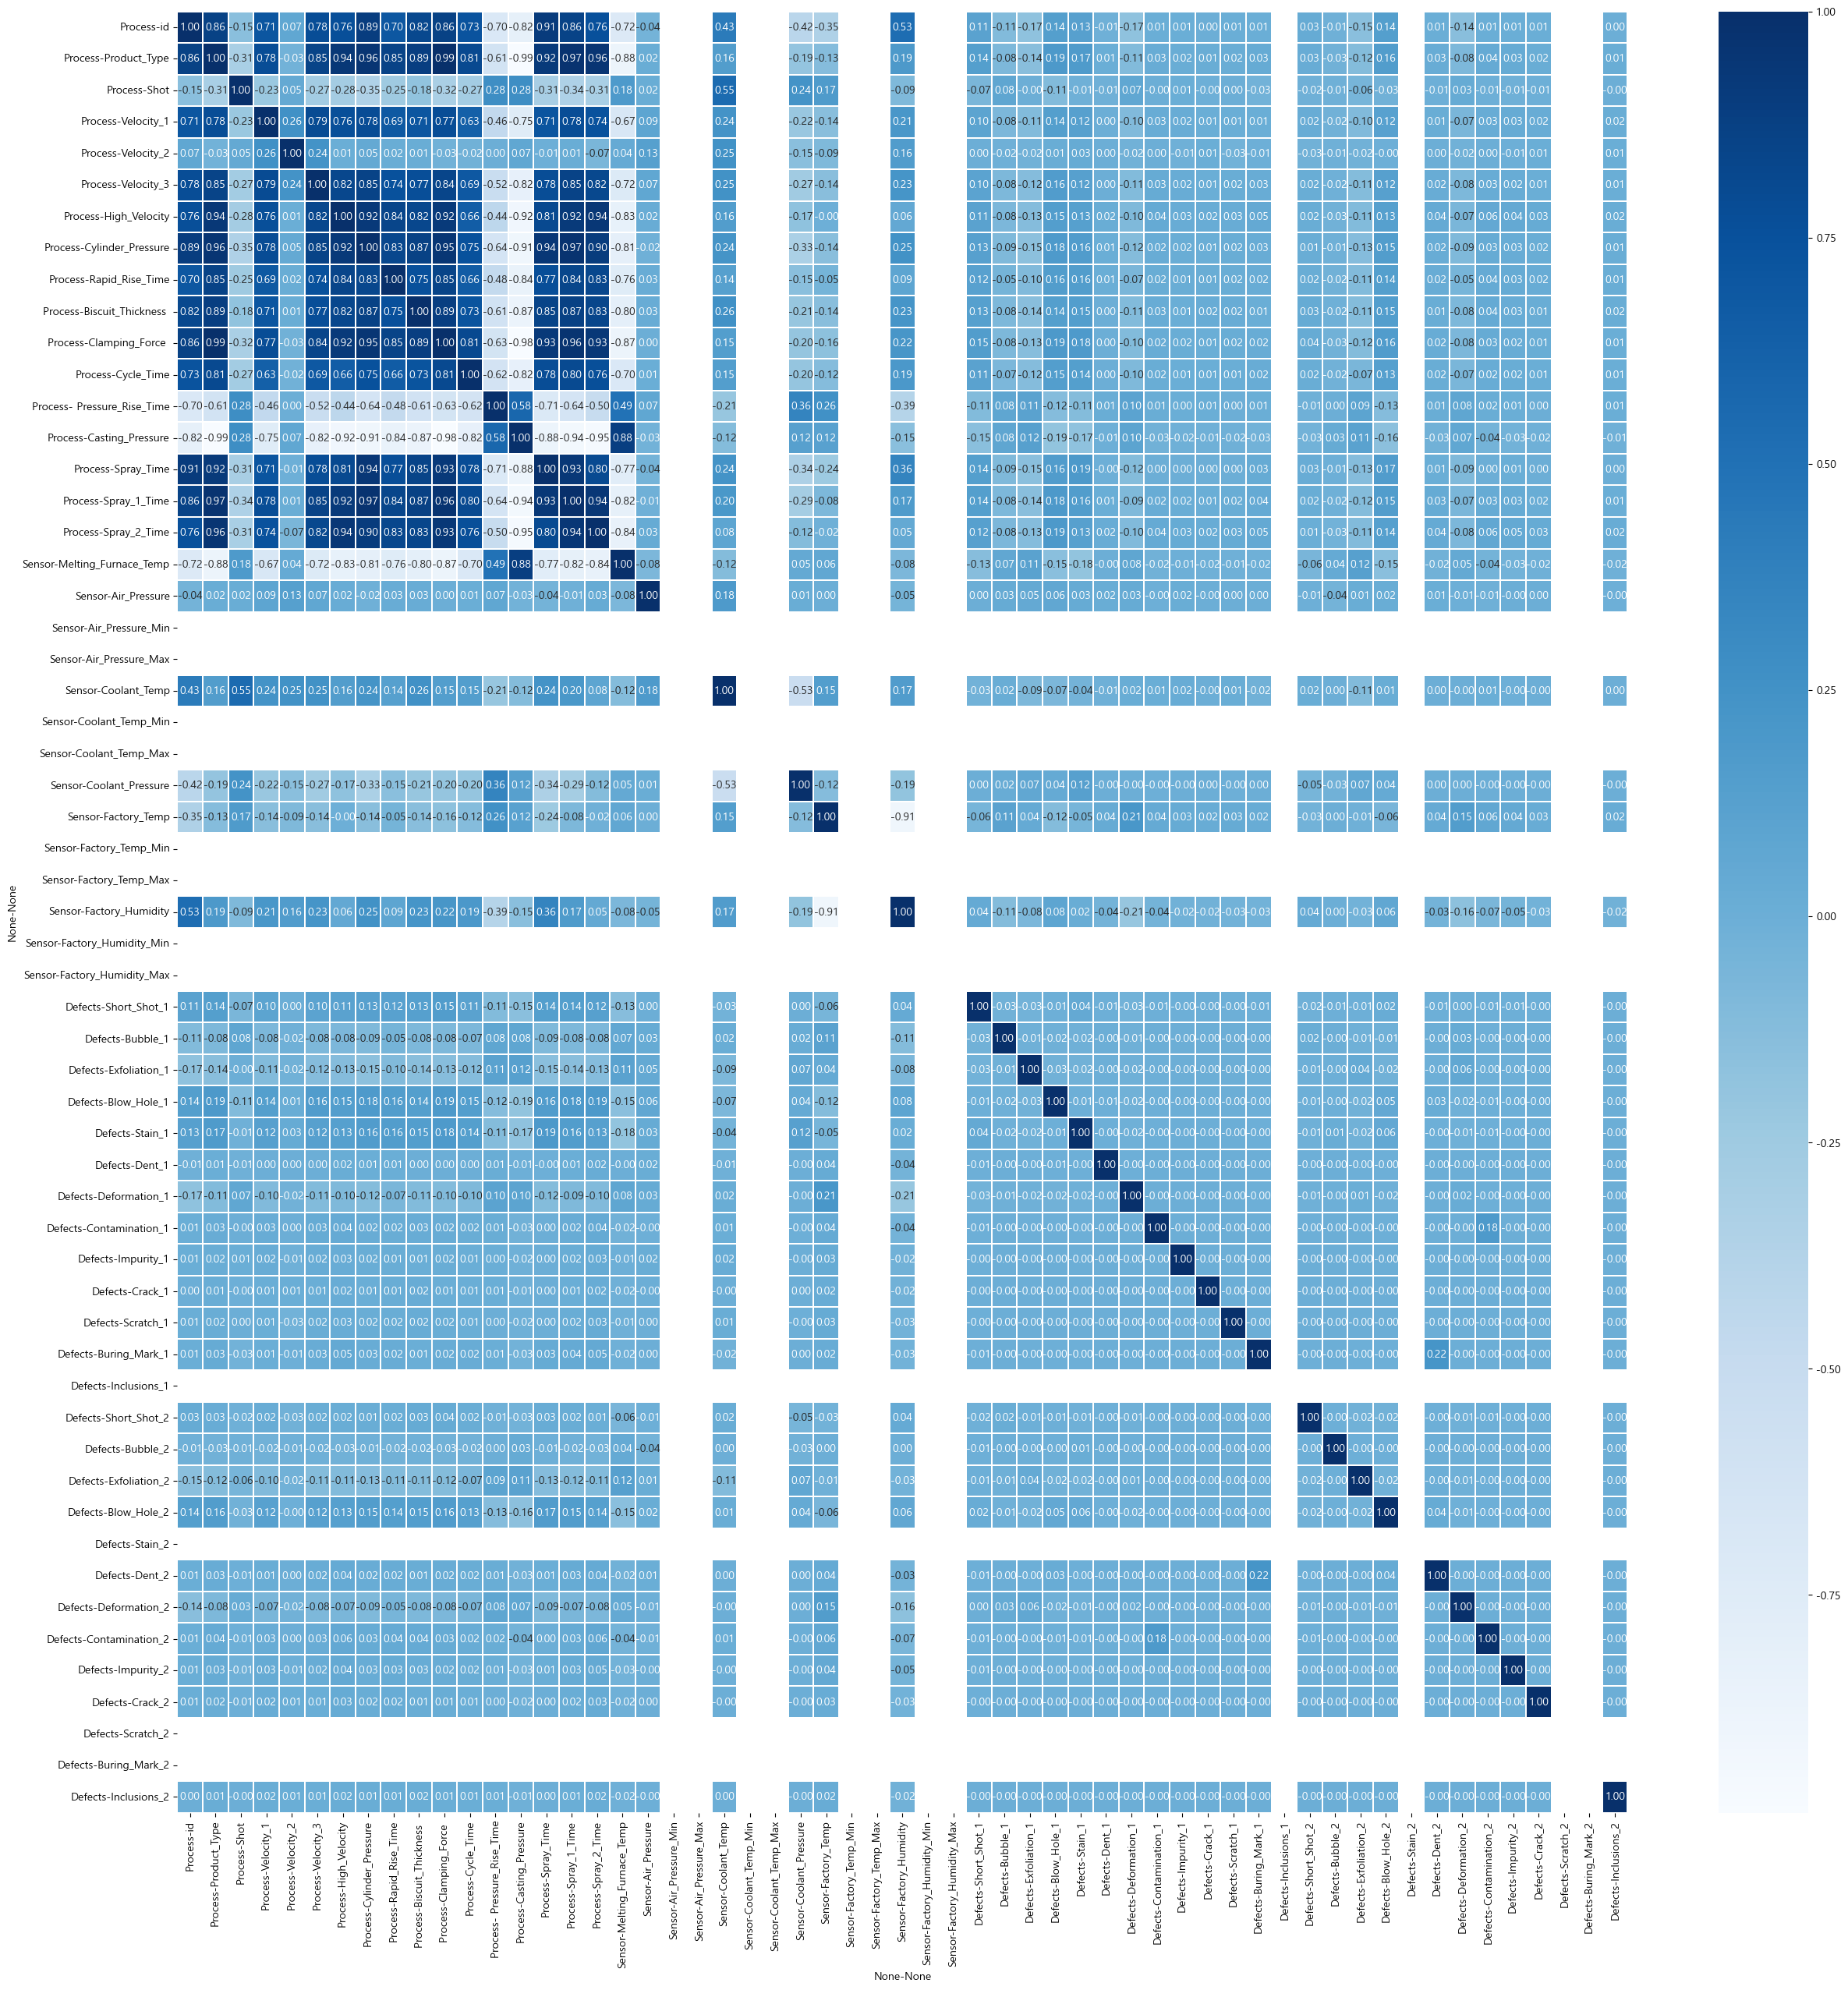

In [9]:
# 변수간 상관관계 파악 히트맵 (Given)
plt.subplots(figsize = (30,30))
sns.heatmap(data = df.corr(),linewidth = 0.1,annot = True,fmt = '.2f',cmap = 'Blues')

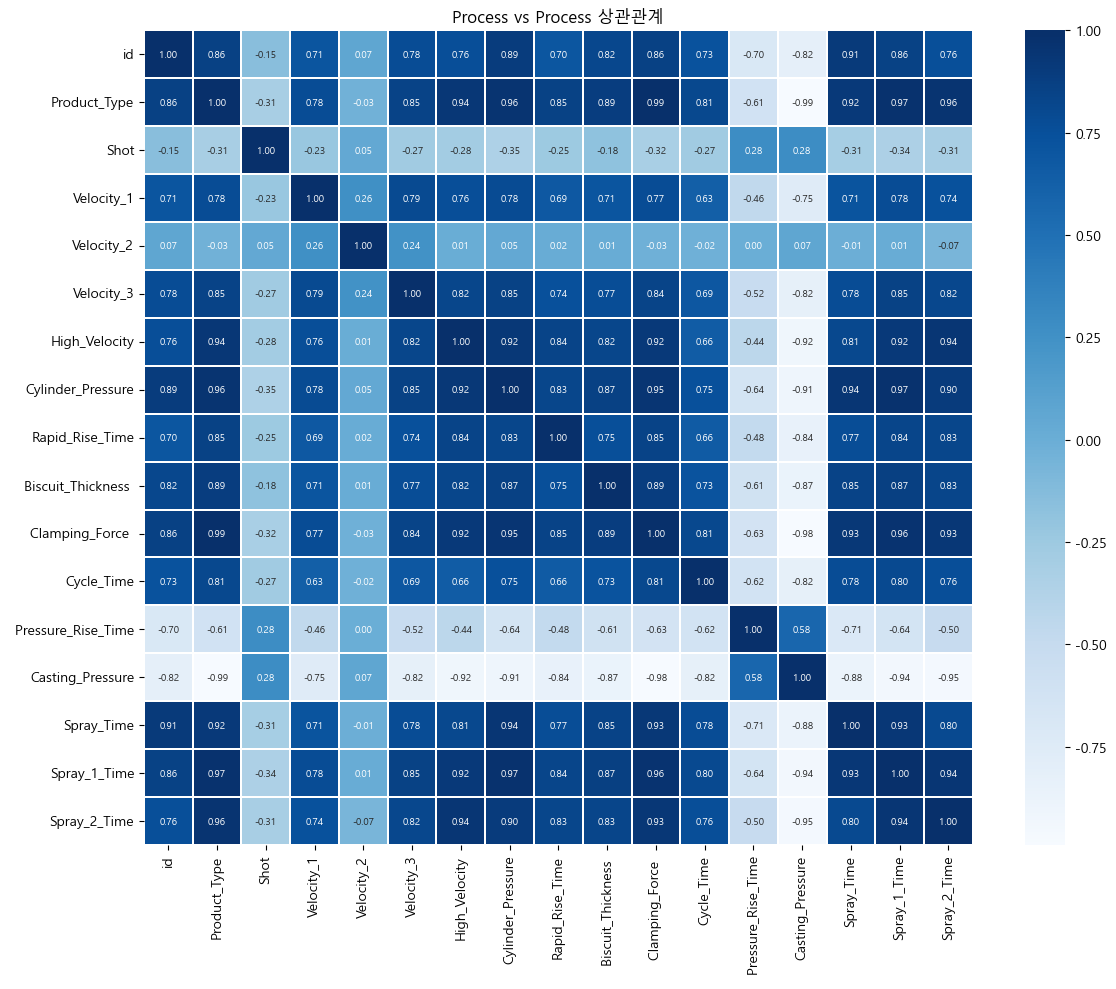

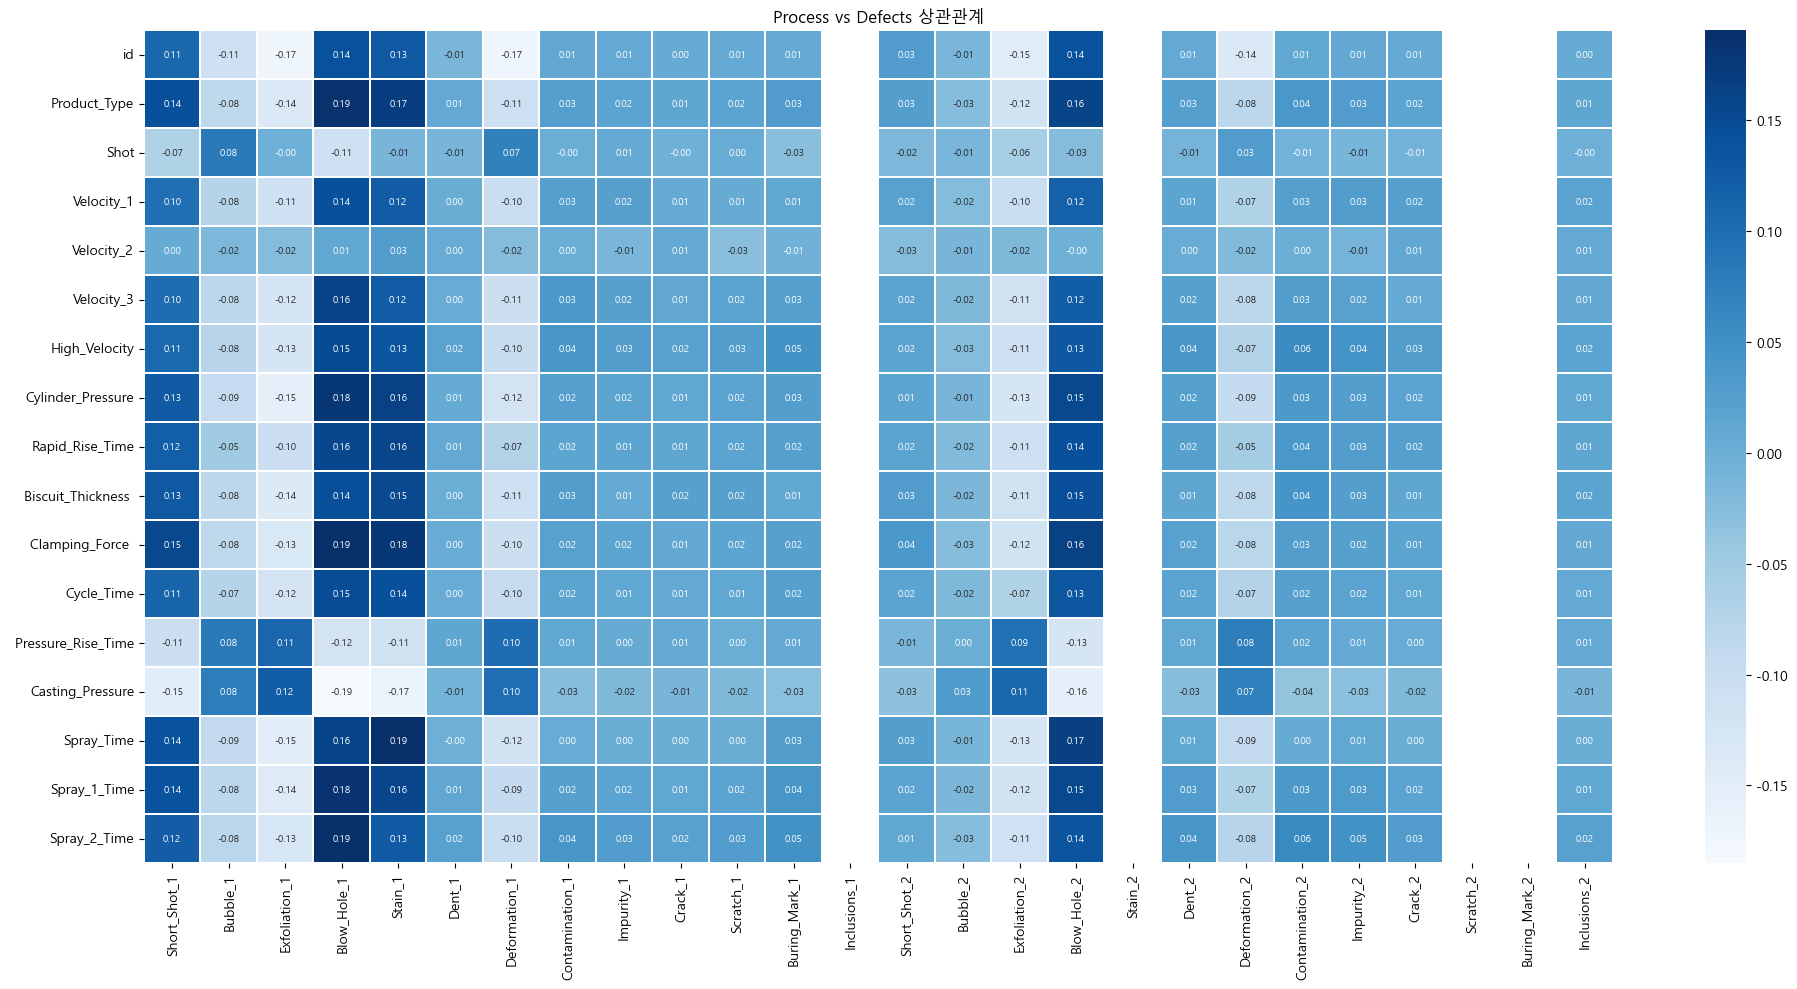

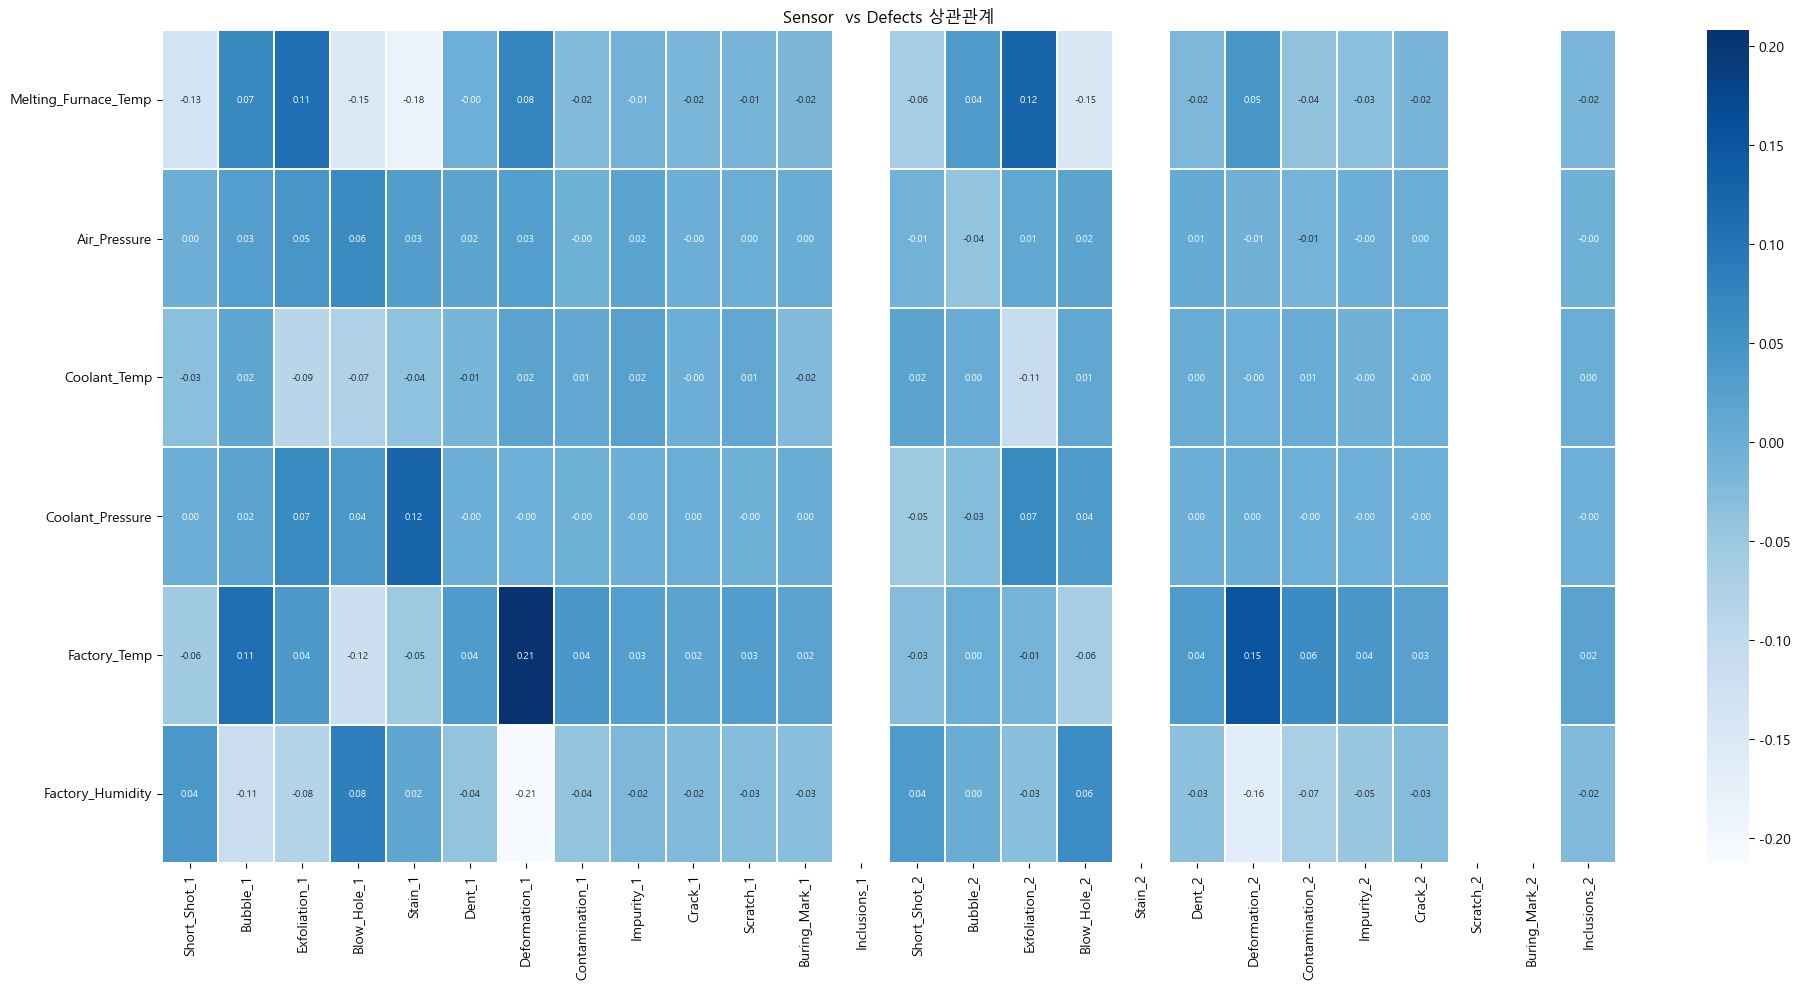

In [10]:
# (수정) 상관관계 히트맵 3종: Process vs Process / Process vs Defects / Sensor vs Defects
# - Process vs Defects, Sensor vs Defects에서도 annot(상관계수 수치)이 보이도록 수정
# - 결측/비수치 값은 숫자 변환 후 중앙값으로 대체(상관계수 계산을 위해)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_defects = _get_group_df(df, "Defects")

# min/max 컬럼 제외한 Process/Sensor만 사용(사용자 요청 반영)
proc_cols = [c for c in df_process.columns if not _is_minmax_col(c)]
sens_cols = [c for c in df_sensor.columns  if not _is_minmax_col(c)]

df_proc_use = df_process[proc_cols].apply(pd.to_numeric, errors="coerce")
df_sens_use = df_sensor[sens_cols].apply(pd.to_numeric, errors="coerce")
df_def_use  = df_defects.apply(pd.to_numeric, errors="coerce")

# 결측은 중앙값으로 대체
df_proc_use = df_proc_use.fillna(df_proc_use.median(numeric_only=True))
df_sens_use = df_sens_use.fillna(df_sens_use.median(numeric_only=True))
df_def_use  = df_def_use.fillna(0)

# 1) Process vs Process
proc_proc_corr = df_proc_use.corr()

# 2) Process vs Defects (행: Process, 열: Defects)
corr_all_proc_def = pd.concat([df_proc_use, df_def_use], axis=1).corr()
proc_def_corr = corr_all_proc_def.loc[df_proc_use.columns, df_def_use.columns]

# 3) Sensor vs Defects (행: Sensor, 열: Defects)
corr_all_sens_def = pd.concat([df_sens_use, df_def_use], axis=1).corr()
sens_def_corr = corr_all_sens_def.loc[df_sens_use.columns, df_def_use.columns]


def plot_heatmap(mat: pd.DataFrame, title: str, figsize=(18, 10), annot: bool = True, save_path=None) -> None:
    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        mat,
        linewidths=0.1,
        annot=annot,
        fmt=".2f",
        cmap="Blues",
        center=0,
        annot_kws={"size": 7}
    )
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=220)
    plt.show()


plot_heatmap(proc_proc_corr, "Process vs Process 상관관계", figsize=(12, 10), annot=True, save_path="eda_plots/heatmap_process_process.png")
plot_heatmap(proc_def_corr,  "Process vs Defects 상관관계", figsize=(20, 10), annot=True, save_path="eda_plots/heatmap_process_defects.png")
plot_heatmap(sens_def_corr,  "Sensor  vs Defects 상관관계", figsize=(20, 10), annot=True, save_path="eda_plots/heatmap_sensor_defects.png")


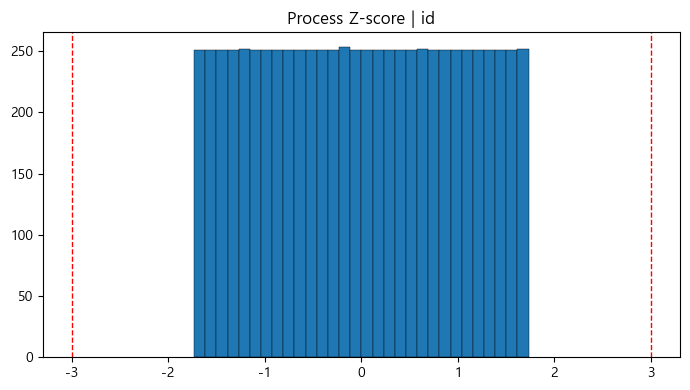

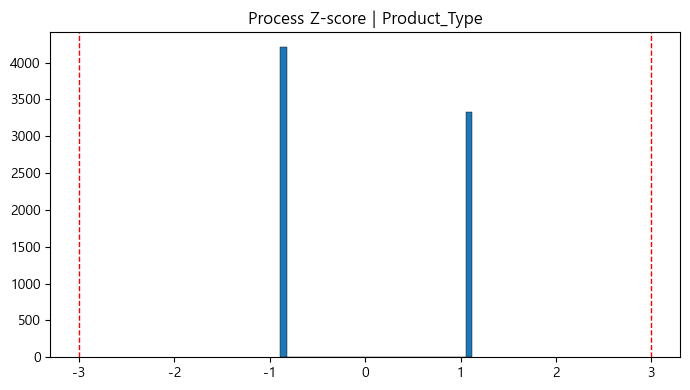

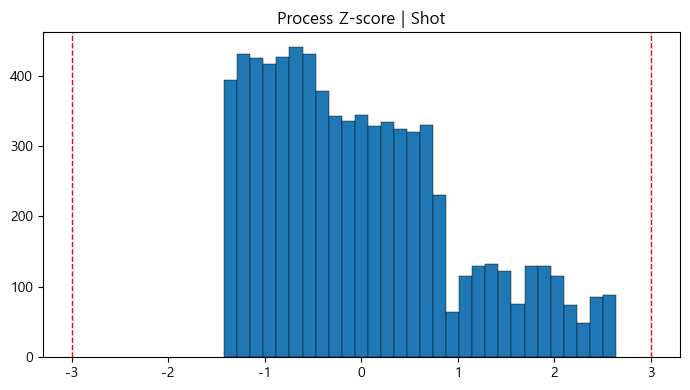

[Process] Z-score 히스토그램 저장 완료: 17개. 저장 폴더: eda_plots/zscore/process


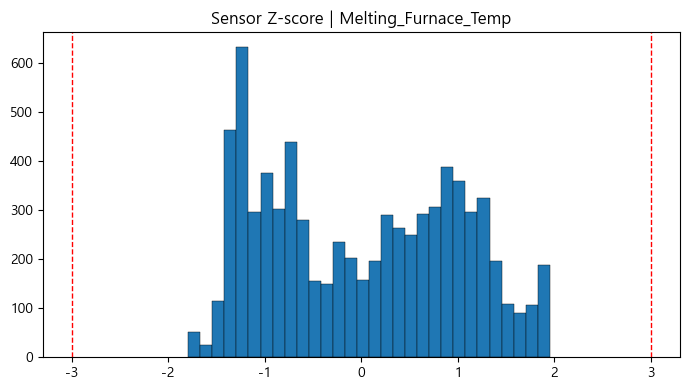

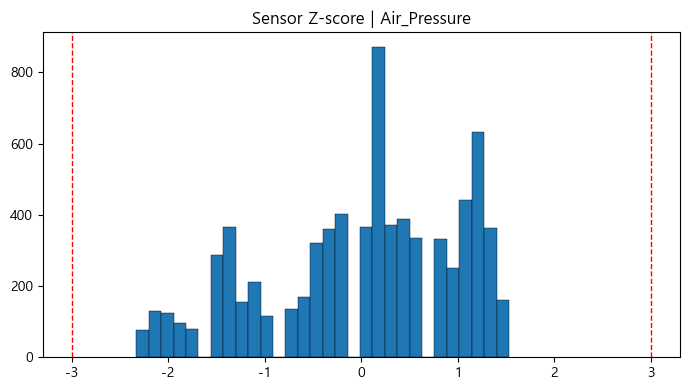

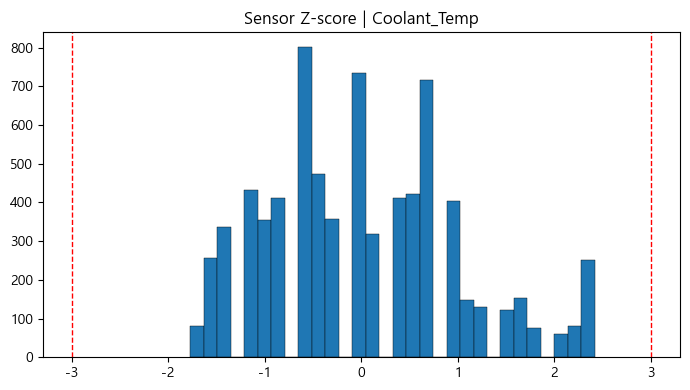

[Sensor] Z-score 히스토그램 저장 완료: 6개. 저장 폴더: eda_plots/zscore/sensor
[Process] |z|>3.0 이상치 요약
- 이상치가 1개 이상 포함된 행(row) 수: 221
- 셀(cell) 단위 이상치 총 개수: 279
[Sensor] |z|>3.0 이상치 요약
- 이상치가 1개 이상 포함된 행(row) 수: 2
- 셀(cell) 단위 이상치 총 개수: 2


,outlier_count,outlier_rate
Velocity_2,144,0.019111
Biscuit_Thickness,36,0.004778
Rapid_Rise_Time,22,0.002920
Velocity_1,22,0.002920
Velocity_3,18,0.002389
Cycle_Time,15,0.001991
High_Velocity,14,0.001858
Pressure_Rise_Time,4,0.000531
Cylinder_Pressure,4,0.000531
id,0,0.000000


,outlier_count,outlier_rate
Factory_Temp,2,0.000265
Melting_Furnace_Temp,0,0.000000
Air_Pressure,0,0.000000
Coolant_Temp,0,0.000000
Coolant_Pressure,0,0.000000
Factory_Humidity,0,0.000000


In [11]:
# (수정) Process / Sensor Z-score 변환 후: "각 컬럼당 1장" 분포 저장 (+ min/max 컬럼 제외) + 이상치(|z|>3) 개수
# - z-score는 변수 스케일 차이를 제거한 상태에서 분포 형태/극단값을 비교할 때 유용함.
# - 이상치 기준: |z| > 3 (1차 점검 기준)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from IPython.display import display

Z_THRESHOLD = 3.0


def zscore_df(df_in: pd.DataFrame) -> pd.DataFrame:
    df_num = df_in.apply(pd.to_numeric, errors="coerce")
    df_num = df_num.fillna(df_num.median(numeric_only=True))
    scaler = StandardScaler()
    z = pd.DataFrame(scaler.fit_transform(df_num.values), columns=df_num.columns, index=df_num.index)
    return z


def save_zscore_hist_per_column(z_df: pd.DataFrame, group_name: str, out_dir: str, bins: int = 30, show_n: int = 3) -> None:
    os.makedirs(out_dir, exist_ok=True)

    saved = 0
    shown = 0

    for c in z_df.columns:
        col_label = str(c)
        safe = _safe_filename(col_label)
        save_path = os.path.join(out_dir, f"{safe}.png")

        x = pd.to_numeric(z_df[c], errors="coerce").dropna()
        if x.empty:
            continue

        plt.figure(figsize=(7, 4))
        plt.hist(x, bins=bins, linewidth=0.3, edgecolor="black")

        # 이상치 기준선 추가 
        plt.axvline(+Z_THRESHOLD, color="red", linestyle="--", linewidth=1)
        plt.axvline(-Z_THRESHOLD, color="red", linestyle="--", linewidth=1)

        plt.title(f"{group_name} Z-score | {col_label}")
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches="tight", dpi=200)

        saved += 1
        if shown < show_n:
            plt.show()
            shown += 1
        else:
            plt.close()

    print(f"[{group_name}] Z-score 히스토그램 저장 완료: {saved}개. 저장 폴더: {out_dir}")


# min/max 컬럼 제외한 Process/Sensor만 선택
proc_cols = [c for c in df_process.columns if not _is_minmax_col(c)]
sens_cols = [c for c in df_sensor.columns  if not _is_minmax_col(c)]

df_proc_use = df_process[proc_cols]
df_sens_use = df_sensor[sens_cols]

# z-score 변환
z_proc = zscore_df(df_proc_use)
z_sens = zscore_df(df_sens_use)

# z-score 분포(컬럼별) 저장
save_zscore_hist_per_column(z_proc, "Process", out_dir="eda_plots/zscore/process", bins=30, show_n=3)
save_zscore_hist_per_column(z_sens, "Sensor",  out_dir="eda_plots/zscore/sensor",  bins=30, show_n=3)

# 이상치 집계(|z| > 3)
def outlier_summary(z_df: pd.DataFrame, group_name: str) -> pd.DataFrame:
    mask = z_df.abs() > Z_THRESHOLD
    out_cnt = mask.sum(axis=0)
    out_rate = (out_cnt / len(z_df)).rename("outlier_rate")
    summary = pd.DataFrame({
        "outlier_count": out_cnt,
        "outlier_rate": out_rate
    }).sort_values("outlier_count", ascending=False)

    rows_with_outlier = int(mask.any(axis=1).sum())
    total_outlier_cells = int(mask.sum().sum())

    print(f"[{group_name}] |z|>{Z_THRESHOLD} 이상치 요약")
    print(f"- 이상치가 1개 이상 포함된 행(row) 수: {rows_with_outlier}")
    print(f"- 셀(cell) 단위 이상치 총 개수: {total_outlier_cells}")
    return summary

proc_out_summary = outlier_summary(z_proc, "Process")
sens_out_summary = outlier_summary(z_sens, "Sensor")

display(proc_out_summary.head(20))
display(sens_out_summary.head(20))


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

pd.set_option("display.max_colwidth", None)   # 문자열 컬럼 생략 금지
pd.set_option("display.width", 2000)          # 출력 폭 늘리기(환경에 따라 효과)
pd.set_option("display.max_columns", None)    # 컬럼 생략 금지

# =========================
# 설정
# =========================
alpha = 0.05
min_n_per_group = 5   # 정상/불량 각각 최소 표본 수
top_k = 5

# =========================
# 컬럼/이름 유틸
# =========================
def is_multiindex_cols(d: pd.DataFrame) -> bool:
    return isinstance(d.columns, pd.MultiIndex)

def defect_display_name(col):
    # MultiIndex: ('Defects','Deformation_1') -> 'Deformation_1'
    if isinstance(col, tuple) and len(col) >= 2:
        return str(col[1])
    return str(col)

def feature_display_name(col):
    # MultiIndex: ('Process','Spray_Time') -> 'Process_Spray_Time'
    if isinstance(col, tuple) and len(col) >= 2:
        return f"{col[0]}_{col[1]}"
    return str(col)

def _base_defect_name(name: str) -> str:
    """
    cavity suffix(_1/_2) 제거해서 base defect 이름 만들기
    - Bubble_1, Bubble_2 -> Bubble
    - Short_Shot_1 -> Short_Shot
    """
    if name.endswith("_1") or name.endswith("_2"):
        return name[:-2]
    return name

def get_defect_groups(d: pd.DataFrame):
    """
    Defects 컬럼을 'cavity 통합' 기준으로 그룹핑:
    - base_defect -> [해당하는 defect 컬럼들(_1/_2 등)]
    """
    # 1) defect 컬럼 먼저 수집
    if is_multiindex_cols(d):
        defect_cols = [c for c in d.columns if str(c[0]).lower() == "defects"]
    else:
        cols = list(d.columns)
        cand = [c for c in cols if "defect" in str(c).lower()]
        if len(cand) == 0:
            cand = [c for c in cols if str(c).endswith("_1") or str(c).endswith("_2")]

        defect_cols = []
        for c in cand:
            vals = pd.to_numeric(d[c], errors="coerce").dropna().unique()
            if len(vals) == 0:
                continue
            try:
                vv = set(pd.Series(vals).astype(int).unique())
            except Exception:
                continue
            if vv.issubset({0, 1}):
                defect_cols.append(c)

    if len(defect_cols) == 0:
        return {}

    # 2) base defect 기준 그룹핑
    groups = {}
    for c in defect_cols:
        nm = defect_display_name(c)
        base = _base_defect_name(nm)
        groups.setdefault(base, []).append(c)

    return groups

def get_feature_cols(d: pd.DataFrame, defect_cols_flat):
    """
    공정/센서 피처 자동 수집:
    - MultiIndex: Process/Sensor
    - Flat: defect_cols 제외 + 수치형만
    """
    if is_multiindex_cols(d):
        feats = [c for c in d.columns if str(c[0]) in ["Process", "Sensor"]]
        # Product_Type 제외(원하시면 이 줄 주석)
        feats = [c for c in feats if not (str(c[0]) == "Process" and str(c[1]) == "Product_Type")]
        return feats

    feats = [c for c in d.columns if c not in defect_cols_flat]
    feats = [c for c in feats if pd.api.types.is_numeric_dtype(d[c])]
    return feats

# =========================
# 대상 DF
# =========================
d = df.copy()

# ---- cavity 통합 defect 그룹 생성 ----
defect_groups = get_defect_groups(d)
if len(defect_groups) == 0:
    raise ValueError("불량(Defects) 컬럼을 찾지 못했습니다. 컬럼 구조를 확인해 주세요.")

# feature 추출용으로 defect 컬럼 전체(flat list)도 필요
all_defect_cols = [c for cols in defect_groups.values() for c in cols]
feature_cols = get_feature_cols(d, all_defect_cols)
if len(feature_cols) == 0:
    raise ValueError("공정/센서(feature) 컬럼을 찾지 못했습니다. 컬럼 구조를 확인해 주세요.")

print(f"[INFO] defect groups(base)={len(defect_groups)} | defect cols(total)={len(all_defect_cols)} | feature cols={len(feature_cols)}")

# =========================
# 불량별 Welch t-test (cavity 통합 OR)
# =========================
rows = []
skipped = []

for base_defect, cols in defect_groups.items():
    # y = OR(해당 base defect에 속한 모든 cavity 컬럼)
    # - 결측은 0 처리
    yy = None
    for c in cols:
        s = pd.to_numeric(d[c], errors="coerce").fillna(0).astype(int)
        yy = s if yy is None else (yy | s)

    y = yy.astype(int)

    idx1 = (y == 1)
    idx0 = (y == 0)
    n_defect = int(idx1.sum())
    n_good = int(idx0.sum())

    if n_good < min_n_per_group or n_defect < min_n_per_group:
        skipped.append({
            "defect": base_defect,
            "n_good": n_good,
            "n_defect": n_defect,
            "reason": f"min_n_per_group({min_n_per_group}) 미만",
            "merged_cols": ", ".join([defect_display_name(c) for c in cols])
        })
        continue

    for f in feature_cols:
        x0 = pd.to_numeric(d.loc[idx0, f], errors="coerce").to_numpy(dtype=float)
        x1 = pd.to_numeric(d.loc[idx1, f], errors="coerce").to_numpy(dtype=float)

        t_stat, p_val = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")

        rows.append({
            "defect": base_defect,  # ✅ cavity 통합 이름
            "feature": feature_display_name(f),
            "n_good": n_good,
            "n_defect": n_defect,
            "p_value": p_val
        })

ttest_df = pd.DataFrame(rows)
skipped_df = pd.DataFrame(skipped)

if ttest_df.empty:
    print("유효 표본 조건을 만족하는 불량이 없어 결과가 비어 있습니다.")
    if not skipped_df.empty:
        display(skipped_df)
    raise SystemExit

# 유의 여부
ttest_df["is_sig"] = ttest_df["p_value"] < alpha

# =========================
# (1) 불량별 유의 변수 개수 요약 (alpha=0.05)  ← 스샷 포맷 유지
# =========================
summary_df = (
    ttest_df.groupby("defect", as_index=False)
    .agg(
        n_good=("n_good", "max"),
        n_defect=("n_defect", "max"),
        sig_p_cnt=("is_sig", "sum"),
    )
    .sort_values("sig_p_cnt", ascending=False)
    .reset_index(drop=True)
)

print(f"불량별 유의 변수 개수 요약 (alpha={alpha}):")
display(summary_df)

# =========================
# (2) 불량별 요약 + Top5 변수(p<alpha)  ← 스샷 포맷 유지
# =========================
def _top5_vars_str(g: pd.DataFrame) -> str:
    gg = g[g["is_sig"]].sort_values("p_value", ascending=True).head(top_k)
    if gg.empty:
        return ""
    return ", ".join(gg["feature"].tolist())

top5_series = (
    ttest_df.groupby("defect")
    .apply(_top5_vars_str)
    .rename("top5_vars(p<alpha)")
    .reset_index()
)

summary_top5_df = summary_df.merge(top5_series, on="defect", how="left")

print("불량별 요약 + Top5 변수(p<alpha):")
display(summary_top5_df)

# =========================
# (옵션) 스킵 목록
# =========================
if not skipped_df.empty:
    print("\n[SKIPPED] 표본 부족으로 스킵된 불량 목록:")
    display(skipped_df.sort_values("n_defect"))


# 참고자료
# - 독립표본 t-검정(개념/절차): https://ms2063.tistory.com/11
# - 독립표본/대응표본/단일표본 구분 요약: https://woogong80.tistory.com/234
# - equal_var=False(Welch) 언급 포함 t-test 설명: https://kiminchae.tistory.com/28
# - pd.to_numeric(errors='coerce') 설명: https://velog.io/@xenrose/Pandas-tonumeric
# - pandas groupby/agg 사용법: https://velog.io/@ddoy_eon/Python-pivot-table-groupby-getgroup-agg-%EC%82%AC%EC%9A%A9%ED%95%98%EA%B8%B0
# - pandas concat 빈 리스트(ValueError: No objects to concatenate) 처리: https://workauto.tistory.com/entry/pandas-ValueError-No-objects-to-concatenate-%EC%98%A4%EB%A5%98-%ED%95%B4%EA%B2%B0%ED%95%98%EA%B8%B0


[INFO] defect groups(base)=13 | defect cols(total)=26 | feature cols=30


c:\Users\xcv54\workspace\develop_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\xcv54\workspace\develop_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\xcv54\workspace\develop_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\xcv54\workspace\develop_project\.venv\Lib\s

불량별 유의 변수 개수 요약 (alpha=0.05):


c:\Users\xcv54\workspace\develop_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,defect,n_good,n_defect,sig_p_cnt
0,Stain,7346,189,22
1,Blow_Hole,7172,363,21
2,Bubble,7456,79,21
3,Exfoliation,7240,295,21
4,Deformation,7366,169,20
5,Short_Shot,6865,670,18
6,Contamination,7524,11,17
7,Impurity,7528,7,16
8,Buring_Mark,7530,5,15
9,Dent,7524,11,6


불량별 요약 + Top5 변수(p<alpha):


C:\Users\xcv54\AppData\Local\Temp\ipykernel_3348\183817067.py:201: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_top5_vars_str)


,defect,n_good,n_defect,sig_p_cnt,top5_vars(p<alpha)
0,Stain,7346,189,22,"Process_Casting_Pressure, Process_Cycle_Time, Process_Spray_2_Time, Process_Spray_1_Time, Process_Spray_Time"
1,Blow_Hole,7172,363,21,"Process_Cylinder_Pressure, Process_High_Velocity, Process_Cycle_Time, Process_Clamping_Force , Process_Spray_1_Time"
2,Bubble,7456,79,21,"Process_Cycle_Time, Process_Clamping_Force , Process_Spray_Time, Process_Casting_Pressure, Process_Cylinder_Pressure"
3,Exfoliation,7240,295,21,"Process_Cylinder_Pressure, Process_High_Velocity, Process_Spray_2_Time, Process_Clamping_Force , Process_Casting_Pressure"
4,Deformation,7366,169,20,"Process_id, Process_High_Velocity, Process_Cylinder_Pressure, Process_Spray_2_Time, Process_Casting_Pressure"
5,Short_Shot,6865,670,18,"Sensor_Melting_Furnace_Temp, Process_Casting_Pressure, Process_Clamping_Force , Process_Spray_1_Time, Process_Spray_Time"
6,Contamination,7524,11,17,"Process_Spray_1_Time, Process_Spray_2_Time, Process_Casting_Pressure, Process_Cycle_Time, Process_Cylinder_Pressure"
7,Impurity,7528,7,16,"Process_Spray_2_Time, Process_Casting_Pressure, Process_Cylinder_Pressure, Process_High_Velocity, Process_Clamping_Force"
8,Buring_Mark,7530,5,15,"Process_Cylinder_Pressure, Process_Casting_Pressure, Process_Spray_2_Time, Process_id, Process_High_Velocity"
9,Dent,7524,11,6,"Sensor_Factory_Humidity, Sensor_Factory_Temp, Process_ Pressure_Rise_Time, Process_Spray_2_Time, Process_High_Velocity"



[SKIPPED] 표본 부족으로 스킵된 불량 목록:


,defect,n_good,n_defect,reason,merged_cols
2,Inclusions,7534,1,min_n_per_group(5) 미만,"Inclusions_1, Inclusions_2"
1,Scratch,7533,2,min_n_per_group(5) 미만,"Scratch_1, Scratch_2"
0,Crack,7532,3,min_n_per_group(5) 미만,"Crack_1, Crack_2"


In [12]:
# 그룹별 컬럼 나누기
defect_cols  = [c for c in df.columns if c[0] == 'Defects']
process_cols = [c for c in df.columns if c[0] == 'Process']
sensor_cols  = [c for c in df.columns if c[0] == 'Sensor']
product_col  = ('Process', 'Product_Type')

In [13]:
# 결측치 처리하기 
# 중앙값으로 결측치를 대체함 -> 이상치 영향을 평균값보다 덜 받는다
for col in sensor_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
# 0 보다 큰 defects 불량으로 취급
# astype -> True/False를 0/1로 변환 
df[defect_cols] = (df[defect_cols] > 0).astype(int)

In [15]:
group_defect = {
    "충전불량": [
        ("Defects", "Short_Shot_1"), ("Defects", "Short_Shot_2")
    ],
    "기포/내부": [
        ("Defects", "Bubble_1"), ("Defects", "Blow_Hole_1"),
        ("Defects", "Bubble_2"), ("Defects", "Blow_Hole_2")
    ],
    "표면손상": [
        ("Defects", "Dent_1"), ("Defects", "Scratch_1"),
        ("Defects", "Stain_1"), ("Defects", "Buring_Mark_1"),
        ("Defects", "Exfoliation_1"),
        ("Defects", "Dent_2"), ("Defects", "Scratch_2"),
        ("Defects", "Stain_2"), ("Defects", "Buring_Mark_2"),
        ("Defects", "Exfoliation_2")
    ],
    "기타": [
        ("Defects", "Crack_1"), ("Defects", "Deformation_1"),
        ("Defects", "Crack_2"), ("Defects", "Deformation_2"),
        ("Defects", "Impurity_1"), ("Defects", "Contamination_1"), ("Defects", "Inclusions_1"),
        ("Defects", "Impurity_2"), ("Defects", "Contamination_2"), ("Defects", "Inclusions_2")
    ]
}

In [16]:
X_all = df[process_cols + sensor_cols].copy()

In [17]:
# Cavity 그룹중 하나라도 불량이면 불량으로 취급
Y_group = pd.DataFrame(index = df.index)
for gname, cols in group_defect.items():
    cols_exist = [c for c in cols if c in df.columns]  # 혹시 누락 컬럼 방지
    Y_group[gname] = (df[cols_exist].max(axis=1)).astype(int)

In [18]:
# 상수 컬럼 제거
nunique = X_all.nunique()
constant_cols = nunique[nunique <= 1].index
X_all = X_all.drop(columns=constant_cols)

# id/Shot 제거
cols_to_drop = [('Process', 'id'), ('Process', 'Shot')]
cols_to_drop = [c for c in cols_to_drop if c in X_all.columns]
X_all = X_all.drop(columns=cols_to_drop)

In [19]:
# 멀티 컬럼을 문자열로 바꾸기
X = X_all.copy()
X.columns = [f"{a}|{b}" for a, b in X.columns]

In [20]:
# 총 갯수가 줄어든걸 확인이 가능하다 -> 왜? -> cavity 1,2 동시에 불량이면 하나로 취급하는거 같다

group_defect_count = {}

for gname, cols in group_defect.items():
    cols_exist = [c for c in cols if c in df.columns]
    group_defect_count[gname] = int(df[cols_exist].max(axis = 1).sum())

group_defect_count

{'충전불량': 670, '기포/내부': 442, '표면손상': 500, '기타': 191}

In [ ]:
# Random forest 

rf_results = {}

for gname in Y_group.columns:
    y = Y_group[gname]

    print("\n==============================")
    print(f"[그룹] {gname} | 불량 = {int(y.sum())}")

    # train / test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

    # 구조결함 / 이물만 SMOTE
    if gname == "기타":
        vc = y_train.value_counts()      
        if len(vc) == 2:
            minority_n = vc.min()
            if minority_n >= 2:
                k = min(5, minority_n - 1)
                smote = SMOTE(random_state=42, k_neighbors=k)
                X_train, y_train = smote.fit_resample(X_train, y_train)

    # RandomForest
    rf = RandomForestClassifier(n_estimators = 200, random_state = 42, n_jobs = -1, class_weight = "balanced")
    rf.fit(X_train, y_train)
    
    proba = rf.predict_proba(X_test)[:, 1]
    threshold = 0.68
    pred = (proba >= threshold).astype(int)

    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred, zero_division=0)
    prec = precision_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    cm = confusion_matrix(y_test, pred)
    

    print("Accuracy:", acc)
    print("Recall  :", rec)
    print("Precision:", prec)
    print("F1-score:", f1)
    print(cm)
    

    # 중요 변수
    importance = pd.Series(rf.feature_importances_, index = X.columns).sort_values(ascending=False)
    print("[TOP10 변수]")
    print(importance)

    rf_results[gname] = {
        "accuracy": acc,
        "recall": rec,
        "precision": prec,
        "cm": cm,
        "top10": importance
    }


[그룹] 충전불량 | 불량 = 670
Accuracy: 0.946914399469144
Recall  : 0.4253731343283582
Precision: 0.95
F1-score: 0.5876288659793815
[[1370    3]
 [  77   57]]
[TOP10 변수]
Process|High_Velocity          0.101740
Sensor|Melting_Furnace_Temp    0.096133
Sensor|Factory_Humidity        0.083367
Process|Clamping_Force         0.065918
Sensor|Coolant_Pressure        0.057954
Process|Velocity_3             0.056480
Sensor|Coolant_Temp            0.055338
Process|Cycle_Time             0.053826
Sensor|Factory_Temp            0.052611
Sensor|Air_Pressure            0.051561
Process|Velocity_1             0.046586
Process|Casting_Pressure       0.045869
Process|Velocity_2             0.042426
Process| Pressure_Rise_Time    0.038561
Process|Spray_Time             0.037520
Process|Biscuit_Thickness      0.032860
Process|Rapid_Rise_Time        0.027913
Process|Cylinder_Pressure      0.024447
Process|Spray_2_Time           0.016867
Process|Spray_1_Time           0.009969
Process|Product_Type           0.00205

In [ ]:
xgb_results = {}

for gname in Y_group.columns:
    y = Y_group[gname]

    print("\n==============================")
    print(f"[XGB] {gname} | 불량 = {int(y.sum())}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

    if gname == "기타":
        vc = y_train.value_counts()      
        if len(vc) == 2:
            minority_n = vc.min()
            if minority_n >= 2:
                k = min(5, minority_n - 1)
                smote = SMOTE(random_state=42, k_neighbors=k)
                X_train, y_train = smote.fit_resample(X_train, y_train)
    
    # spw를 붙이면 도움이 된다고 하길래 한번 해봄
    pos = int((y_train == 1).sum()) 
    neg = int((y_train == 0).sum())
    spw = (neg / pos) if pos > 0 else 1


    xgb = XGBClassifier(
        n_estimators = 400,
        learning_rate = 0.05,
        max_depth = 5,
        subsample = 0.9,
        colsample_bytree = 0.9,
        random_state = 42,
        n_jobs = -1,
        eval_metric = "logloss",
        scale_pos_weight = spw # 이게 도움이 된다고 한다
    )
    xgb.fit(X_train, y_train)

    proba = xgb.predict_proba(X_test)[:, 1]
    threshold = 0.68
    pred = (proba >= threshold).astype(int)

    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred, zero_division=0)
    prec = precision_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    cm = confusion_matrix(y_test, pred)
    

    print("Accuracy:", acc)
    print("Recall  :", rec)
    print("Precision:", prec)
    print("F1-score:", f1)
    print(cm)

    top10 = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    print("[TOP10 변수]")
    print(top10)

    xgb_results[gname] = {"accuracy": acc, "recall": rec, "precision": prec, "cm": cm, "top10": top10}


[XGB] 충전불량 | 불량 = 670
Accuracy: 0.9422694094226941
Recall  : 0.6417910447761194
Precision: 0.688
F1-score: 0.6640926640926641
[[1334   39]
 [  48   86]]
[TOP10 변수]
Process|Spray_2_Time           0.174069
Process|Clamping_Force         0.069455
Process|Spray_Time             0.065902
Process|Cycle_Time             0.064375
Sensor|Coolant_Temp            0.055627
Sensor|Coolant_Pressure        0.047837
Process|High_Velocity          0.044925
Sensor|Melting_Furnace_Temp    0.040360
Process|Spray_1_Time           0.040204
Sensor|Air_Pressure            0.039899
dtype: float32

[XGB] 기포/내부 | 불량 = 442
Accuracy: 0.9615129396151294
Recall  : 0.75
Precision: 0.6470588235294118
F1-score: 0.6947368421052632
[[1383   36]
 [  22   66]]
[TOP10 변수]
Process|Clamping_Force         0.111448
Process|Cycle_Time             0.109955
Process|Spray_2_Time           0.079536
Sensor|Coolant_Temp            0.066227
Process|High_Velocity          0.050606
Process|Spray_Time             0.048697
Sensor|Factory_

In [ ]:
lgbm_results = {}

for gname in Y_group.columns:
    y = Y_group[gname]

    print("\n==============================")
    print(f"[LGBM] {gname} | 불량 = {int(y.sum())}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

    if gname == "기타":
        vc = y_train.value_counts()      
        if len(vc) == 2:
            minority_n = vc.min()
            if minority_n >= 2:
                k = min(5, minority_n - 1)
                smote = SMOTE(random_state=42, k_neighbors=k)
                X_train, y_train = smote.fit_resample(X_train, y_train)

    lgbm = LGBMClassifier(
        n_estimators = 600,
        learning_rate = 0.05,
        max_depth = -1,
        num_leaves = 31,
        subsample = 0.9,
        colsample_bytree = 0.9,
        random_state = 42,
        n_jobs = -1,
        verbosity = -1
    )

    lgbm.fit(X_train, y_train)

    proba = lgbm.predict_proba(X_test)[:, 1]
    threshold = 0.68
    pred = (proba >= threshold).astype(int)

    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred, zero_division=0)
    prec = precision_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    cm = confusion_matrix(y_test, pred)
    

    print("Accuracy:", acc)
    print("Recall  :", rec)
    print("Precision:", prec)
    print("F1-score:", f1)
    print(cm)

    top10 = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending = False).head(10)
    print("[TOP10 변수]")
    print(top10)

    lgbm_results[gname] = {
        "accuracy": acc,
        "recall": rec,
        "precision": prec,
        "cm": cm,
        "top10": top10
    }


[LGBM] 충전불량 | 불량 = 670
Accuracy: 0.9688122096881221
Recall  : 0.6567164179104478
Precision: 0.9887640449438202
F1-score: 0.7892376681614349
[[1372    1]
 [  46   88]]
[TOP10 변수]
Process|High_Velocity          2500
Sensor|Melting_Furnace_Temp    2142
Sensor|Factory_Humidity        1631
Process|Velocity_3             1243
Process|Velocity_1             1117
Sensor|Coolant_Pressure        1087
Sensor|Factory_Temp             978
Process|Velocity_2              947
Sensor|Air_Pressure             905
Process|Clamping_Force          867
dtype: int32

[LGBM] 기포/내부 | 불량 = 442
Accuracy: 0.9794293297942933
Recall  : 0.7045454545454546
Precision: 0.9253731343283582
F1-score: 0.8
[[1414    5]
 [  26   62]]
[TOP10 변수]
Process|High_Velocity          2247
Sensor|Melting_Furnace_Temp    2073
Sensor|Factory_Humidity        1702
Process|Velocity_3             1276
Process|Velocity_1             1200
Process|Velocity_2             1174
Sensor|Coolant_Pressure        1075
Sensor|Air_Pressure            

In [ ]:
# =========================
# (수정) 모델 결과 요약 테이블 (+ F1-score 자동 계산 포함)
# - 위의 머신러닝 셀 코드는 수정하지 않음
# - rf_results / xgb_results / lgbm_results(존재 시)만 집계하여 display
# =========================

import pandas as pd
import numpy as np
from IPython.display import display

def _safe_f1(precision, recall):
    """precision/recall로 F1 계산 (둘 중 하나라도 NaN이면 NaN)"""
    if pd.isna(precision) or pd.isna(recall):
        return np.nan
    denom = (precision + recall)
    if denom == 0:
        return 0.0
    return 2 * precision * recall / denom

def _results_to_metrics_df(results: dict, model_name: str) -> pd.DataFrame:
    rows = []
    for defect, d in (results or {}).items():
        if not isinstance(d, dict):
            continue

        acc = d.get("accuracy", np.nan)
        rec = d.get("recall", np.nan)
        pre = d.get("precision", np.nan)

        # (핵심) f1이 dict에 없으면 precision/recall로 계산
        f1_val = d.get("f1", np.nan)
        if pd.isna(f1_val):
            f1_val = _safe_f1(pre, rec)

        rows.append({
            "model": model_name,
            "defect_group": defect,
            "accuracy": acc,
            "precision": pre,
            "recall": rec,
            "f1": f1_val,
        })
    return pd.DataFrame(rows)

def _results_to_topk_long(results: dict, model_name: str, top_k: int = 10) -> pd.DataFrame:
    rows = []
    for defect, d in (results or {}).items():
        if not isinstance(d, dict):
            continue
        top = d.get("top10", None)

        # top10이 Series(중요도)면 head(top_k)로 정리
        if isinstance(top, pd.Series):
            s = top.sort_values(ascending=False).head(top_k)
            for r, (feat, val) in enumerate(s.items(), start=1):
                rows.append({
                    "model": model_name,
                    "defect_group": defect,
                    "rank": r,
                    "feature": str(feat),
                    "importance": float(val) if pd.notna(val) else np.nan,
                })

        # top10이 DataFrame이면 첫 컬럼/두 번째 컬럼을 feature/importance로 가정
        elif isinstance(top, pd.DataFrame) and len(top.columns) >= 1:
            df = top.copy()
            if "feature" not in df.columns:
                df = df.rename(columns={df.columns[0]: "feature"})
            if "importance" not in df.columns and len(df.columns) >= 2:
                df = df.rename(columns={df.columns[1]: "importance"})

            df = df.head(top_k)
            for r, row in enumerate(df.itertuples(index=False), start=1):
                feat = getattr(row, "feature", None)
                imp = getattr(row, "importance", np.nan) if hasattr(row, "importance") else np.nan
                rows.append({
                    "model": model_name,
                    "defect_group": defect,
                    "rank": r,
                    "feature": str(feat),
                    "importance": float(imp) if pd.notna(imp) else np.nan,
                })

        # top10이 list/tuple 형태라면 feature만 나열
        elif isinstance(top, (list, tuple)):
            for r, feat in enumerate(list(top)[:top_k], start=1):
                rows.append({
                    "model": model_name,
                    "defect_group": defect,
                    "rank": r,
                    "feature": str(feat),
                    "importance": np.nan,
                })
        else:
            continue

    return pd.DataFrame(rows)

# 존재하는 결과 dict 자동 수집
_candidates = [
    ("RandomForest", "rf_results"),
    ("XGBoost", "xgb_results"),
    ("LightGBM", "lgbm_results"),
    ("LightGBM", "lgb_results"),
]

found = []
for model_name, var_name in _candidates:
    if var_name in globals() and isinstance(globals()[var_name], dict) and len(globals()[var_name]) > 0:
        found.append((model_name, var_name, globals()[var_name]))

if len(found) == 0:
    print("집계할 결과가 없습니다. (rf_results/xgb_results/lgbm_results가 생성된 뒤에 실행해주세요.)")
else:
    # 1) 불량별 성능 지표 요약(한 표)
    metrics_long = pd.concat([_results_to_metrics_df(res, m) for m, _, res in found], ignore_index=True)

    # 보기 좋은 순서로 정렬(원하시면 순서 바꿔도 됨)
    metric_cols = ["accuracy", "precision", "recall", "f1"]
    metrics_long = metrics_long[["defect_group", "model"] + metric_cols]

    metrics_pivot = (
        metrics_long
        .pivot_table(index="defect_group", columns="model", values=metric_cols, aggfunc="first")
        .sort_index()
    )

    # 컬럼 순서: model -> metric
    metrics_pivot = metrics_pivot.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

    # (추가) 모델별 metric 출력 순서 고정: accuracy → precision → recall → f1
    metric_order = ["accuracy", "precision", "recall", "f1"]
    model_order = [m for (m, _, _) in found]  # found 순서 유지
    # found에 동일 model명이 중복될 수 있어(예: LightGBM) 순서 보존 unique 처리
    _seen = set()
    model_order = [m for m in model_order if (m not in _seen and not _seen.add(m))]

    desired_cols = []
    for m in model_order:
        for met in metric_order:
            if (m, met) in metrics_pivot.columns:
                desired_cols.append((m, met))

    if len(desired_cols) > 0:
        metrics_pivot = metrics_pivot.reindex(columns=pd.MultiIndex.from_tuples(desired_cols))

    display(metrics_pivot)

    # 2) 불량별 Top10 변수(한 표)
    top10_long = pd.concat([_results_to_topk_long(res, m, top_k=10) for m, _, res in found], ignore_index=True)

    top10_feat_wide = (
        top10_long
        .pivot_table(index=["model", "defect_group"], columns="rank", values="feature", aggfunc="first")
        .sort_index()
    )
    top10_feat_wide.columns = [f"rank_{int(c)}_feature" for c in top10_feat_wide.columns]
    display(top10_feat_wide.reset_index())

    # 중요도 값도 같이(가능한 경우에만)
    if "importance" in top10_long.columns and not top10_long["importance"].isna().all():
        top10_imp_wide = (
            top10_long
            .pivot_table(index=["model", "defect_group"], columns="rank", values="importance", aggfunc="first")
            .sort_index()
        )
        top10_imp_wide.columns = [f"rank_{int(c)}_importance" for c in top10_imp_wide.columns]
        display(top10_imp_wide.reset_index())


RandomForest                                 XGBoost            \
                 accuracy precision    recall        f1  accuracy precision   
defect_group                                                                  
기타               0.973457  0.416667  0.131579  0.200000  0.974784  0.500000   
기포/내부            0.960186  0.818182  0.409091  0.545455  0.961513  0.647059   
충전불량             0.946914  0.950000  0.425373  0.587629  0.942269  0.688000   
표면손상             0.959522  0.897959  0.440000  0.590604  0.957532  0.640625   

                                  LightGBM                                
                recall        f1  accuracy precision    recall        f1  
defect_group                                                              
기타            0.184211  0.269231  0.974121  0.466667  0.184211  0.264151  
기포/내부         0.750000  0.694737  0.979429  0.925373  0.704545  0.800000  
충전불량          0.641791  0.664093  0.968812  0.988764  0.656716  0.789238  
표면손상          0.820000  0.719298  0.974784  0.918919  0.680000  0.781609

,model,defect_group,rank_1_feature,rank_2_feature,rank_3_feature,rank_4_feature,rank_5_feature,rank_6_feature,rank_7_feature,rank_8_feature,rank_9_feature,rank_10_feature
0,LightGBM,기타,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Sensor|Coolant_Pressure,Process|Velocity_1,Process|Velocity_3,Process|Velocity_2,Sensor|Air_Pressure,Process| Pressure_Rise_Time,Sensor|Factory_Temp
1,LightGBM,기포/내부,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Process|Velocity_3,Process|Velocity_1,Process|Velocity_2,Sensor|Coolant_Pressure,Sensor|Air_Pressure,Sensor|Factory_Temp,Process| Pressure_Rise_Time
2,LightGBM,충전불량,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Process|Velocity_3,Process|Velocity_1,Sensor|Coolant_Pressure,Sensor|Factory_Temp,Process|Velocity_2,Sensor|Air_Pressure,Process|Clamping_Force
3,LightGBM,표면손상,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Process|Velocity_3,Sensor|Coolant_Pressure,Process|Casting_Pressure,Process|Velocity_1,Sensor|Air_Pressure,Process| Pressure_Rise_Time,Process|Clamping_Force
4,RandomForest,기타,Sensor|Factory_Humidity,Sensor|Factory_Temp,Process|Cycle_Time,Process|Spray_Time,Sensor|Coolant_Pressure,Process|Biscuit_Thickness,Process|Spray_1_Time,Process| Pressure_Rise_Time,Process|High_Velocity,Process|Velocity_3
5,RandomForest,기포/내부,Process|High_Velocity,Sensor|Factory_Humidity,Sensor|Melting_Furnace_Temp,Process|Clamping_Force,Sensor|Factory_Temp,Sensor|Coolant_Temp,Process|Cycle_Time,Sensor|Coolant_Pressure,Sensor|Air_Pressure,Process|Velocity_3
6,RandomForest,충전불량,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Process|Clamping_Force,Sensor|Coolant_Pressure,Process|Velocity_3,Sensor|Coolant_Temp,Process|Cycle_Time,Sensor|Factory_Temp,Sensor|Air_Pressure
7,RandomForest,표면손상,Sensor|Factory_Humidity,Sensor|Coolant_Pressure,Sensor|Melting_Furnace_Temp,Process|High_Velocity,Sensor|Coolant_Temp,Sensor|Air_Pressure,Sensor|Factory_Temp,Process|Velocity_3,Process|Clamping_Force,Process|Velocity_1
8,XGBoost,기타,Sensor|Factory_Humidity,Process|Biscuit_Thickness,Process|Spray_1_Time,Process|Spray_Time,Process|Product_Type,Process|Cycle_Time,Process|Velocity_2,Sensor|Coolant_Pressure,Sensor|Factory_Temp,Process| Pressure_Rise_Time
9,XGBoost,기포/내부,Process|Clamping_Force,Process|Cycle_Time,Process|Spray_2_Time,Sensor|Coolant_Temp,Process|High_Velocity,Process|Spray_Time,Sensor|Factory_Humidity,Process|Spray_1_Time,Sensor|Factory_Temp,Sensor|Melting_Furnace_Temp


,model,defect_group,rank_1_importance,rank_2_importance,rank_3_importance,rank_4_importance,rank_5_importance,rank_6_importance,rank_7_importance,rank_8_importance,rank_9_importance,rank_10_importance
0,LightGBM,기타,1934.000000,1879.000000,1409.000000,1247.000000,1231.000000,1100.000000,1095.000000,1087.000000,1051.000000,946.000000
1,LightGBM,기포/내부,2247.000000,2073.000000,1702.000000,1276.000000,1200.000000,1174.000000,1075.000000,903.000000,881.000000,857.000000
2,LightGBM,충전불량,2500.000000,2142.000000,1631.000000,1243.000000,1117.000000,1087.000000,978.000000,947.000000,905.000000,867.000000
3,LightGBM,표면손상,2582.000000,2132.000000,1861.000000,1419.000000,1074.000000,967.000000,966.000000,927.000000,876.000000,854.000000
4,RandomForest,기타,0.233097,0.166516,0.082064,0.074654,0.063082,0.040543,0.038349,0.037292,0.033532,0.028047
5,RandomForest,기포/내부,0.115387,0.083731,0.079424,0.070884,0.063308,0.061069,0.060121,0.054818,0.054428,0.044583
6,RandomForest,충전불량,0.101740,0.096133,0.083367,0.065918,0.057954,0.056480,0.055338,0.053826,0.052611,0.051561
7,RandomForest,표면손상,0.111087,0.090048,0.087815,0.079535,0.078684,0.072937,0.055784,0.052941,0.045853,0.043574
8,XGBoost,기타,0.417551,0.083259,0.048749,0.048193,0.046155,0.045748,0.041958,0.037658,0.037241,0.034881
9,XGBoost,기포/내부,0.111448,0.109955,0.079536,0.066227,0.050606,0.048697,0.047874,0.046761,0.043229,0.040597


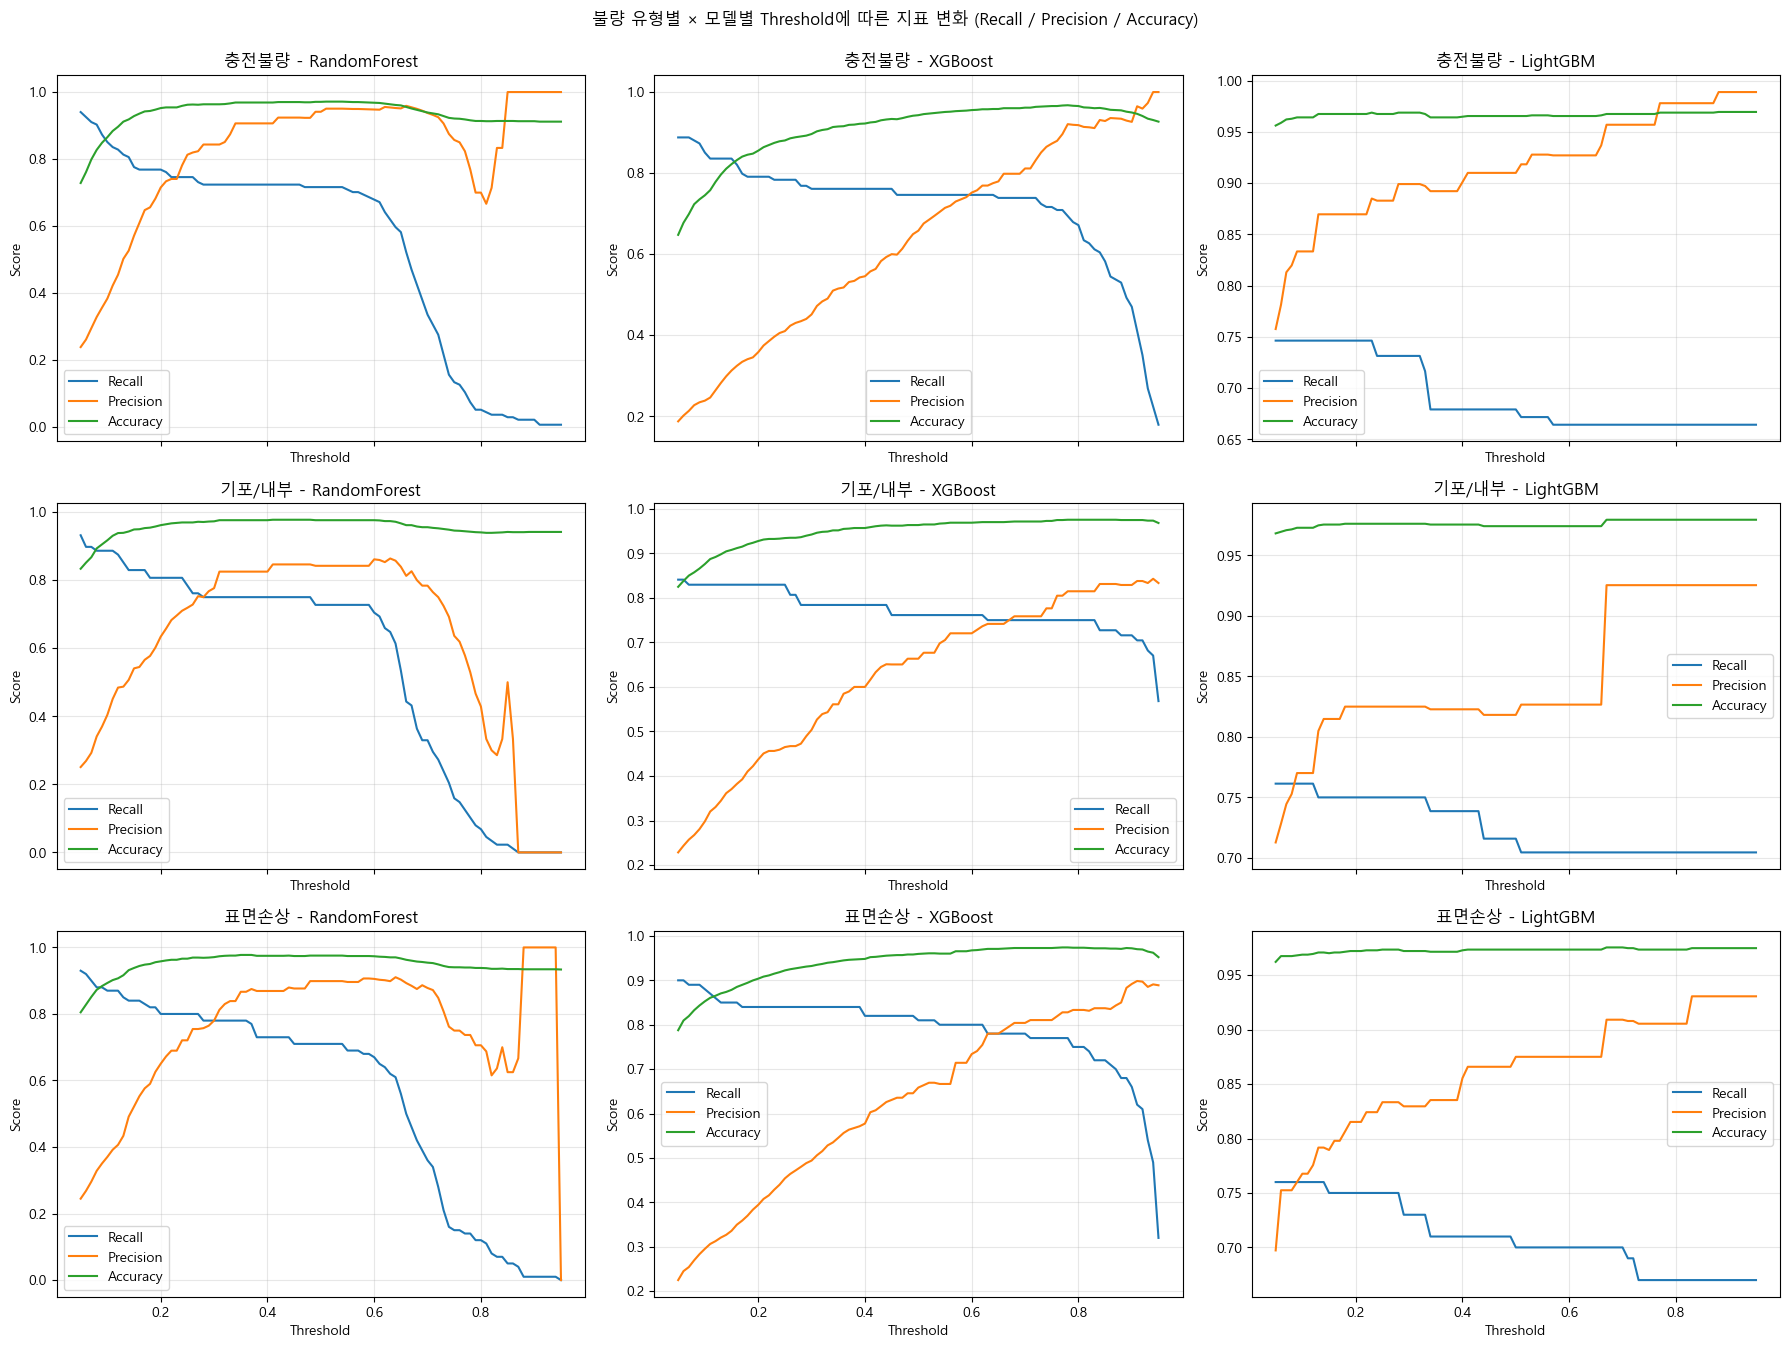

[저장 완료] threshold_curves.png


In [21]:
# =========================
# (추가) Threshold 곡선 그래프(Recall / Precision / Accuracy)
# - 기존 머신러닝 셀 코드는 수정하지 않음
# - 아래 셀은 "새로" 학습/예측을 수행하여 threshold sweep 곡선을 그림
#   (모델 파라미터/SMOTE 적용 로직은 위 셀과 동일하게 맞춤)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mpl.rcParams["font.family"] = "Malgun Gothic"   # 맑은 고딕
mpl.rcParams["axes.unicode_minus"] = False      # 마이너스(-) 깨짐 방지

# ===== 설정 =====
THR_START = 0.05
THR_END   = 0.95
THR_STEP  = 0.01
thresholds = np.round(np.arange(THR_START, THR_END + 1e-12, THR_STEP), 2)

# 표시할 불량 그룹(원하시면 리스트 수정)
# - 예시 그래프와 동일하게 기타는 제외(필요 시 포함 가능)
defect_groups_plot = [g for g in Y_group.columns if g != "기타"]

# ===== 헬퍼 =====
def _maybe_smote_for_misc(gname, X_train, y_train):
    """
    원본 노트북 로직: '기타'만 SMOTE 적용(가능할 때만)
    """
    if gname != "기타":
        return X_train, y_train

    vc = y_train.value_counts()
    if len(vc) == 2:
        minority_n = int(vc.min())
        if minority_n >= 2:
            k = min(5, minority_n - 1)
            smote = SMOTE(random_state=42, k_neighbors=k)
            X_train, y_train = smote.fit_resample(X_train, y_train)
    return X_train, y_train

def _sweep_metrics(y_true, proba, thresholds):
    rows = []
    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        rows.append({
            "threshold": float(thr),
            "accuracy": float(accuracy_score(y_true, pred)),
            "recall": float(recall_score(y_true, pred, zero_division=0)),
            "precision": float(precision_score(y_true, pred, zero_division=0)),
        })
    return pd.DataFrame(rows)

# ===== Sweep 수행 =====
all_rows = []

for gname in defect_groups_plot:
    y = Y_group[gname].astype(int)

    # 동일 split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # (원본 로직) 기타만 SMOTE 적용인데, defect_groups_plot에서는 기타 제외이므로 사실상 미적용
    # 혹시 기타 포함 시에도 동일 로직으로 동작
    X_train_sm, y_train_sm = _maybe_smote_for_misc(gname, X_train, y_train)

    # -------- RandomForest --------
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
    rf.fit(X_train_sm, y_train_sm)
    rf_proba = rf.predict_proba(X_test)[:, 1]

    df_rf = _sweep_metrics(y_test, rf_proba, thresholds)
    df_rf["model"] = "RandomForest"
    df_rf["defect_group"] = gname
    all_rows.append(df_rf)

    # -------- XGBoost --------
    # 원본 노트북 로직: SMOTE 적용 후 spw 계산
    pos = int((y_train_sm == 1).sum())
    neg = int((y_train_sm == 0).sum())
    spw = (neg / pos) if pos > 0 else 1

    xgb = XGBClassifier(
        n_estimators=400,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        scale_pos_weight=spw
    )
    xgb.fit(X_train_sm, y_train_sm)
    xgb_proba = xgb.predict_proba(X_test)[:, 1]

    df_xgb = _sweep_metrics(y_test, xgb_proba, thresholds)
    df_xgb["model"] = "XGBoost"
    df_xgb["defect_group"] = gname
    all_rows.append(df_xgb)

    # -------- LightGBM --------
    lgbm = LGBMClassifier(
        n_estimators=600,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    lgbm.fit(X_train_sm, y_train_sm)
    lgbm_proba = lgbm.predict_proba(X_test)[:, 1]

    df_lgbm = _sweep_metrics(y_test, lgbm_proba, thresholds)
    df_lgbm["model"] = "LightGBM"
    df_lgbm["defect_group"] = gname
    all_rows.append(df_lgbm)

threshold_curve_df = pd.concat(all_rows, ignore_index=True)

# ===== 그래프 출력 =====
model_order = ["RandomForest", "XGBoost", "LightGBM"]
n_rows = len(defect_groups_plot)
n_cols = len(model_order)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows), sharex=True)
if n_rows == 1:
    axes = np.array([axes])  # 1행인 경우 shape 통일

for r, gname in enumerate(defect_groups_plot):
    for c, mname in enumerate(model_order):
        ax = axes[r, c]
        sub = threshold_curve_df[(threshold_curve_df["defect_group"] == gname) & (threshold_curve_df["model"] == mname)].sort_values("threshold")

        # 색 지정 없이 기본 컬러 사이클 사용(파란/주황/초록 순)
        ax.plot(sub["threshold"], sub["recall"], label="Recall")
        ax.plot(sub["threshold"], sub["precision"], label="Precision")
        ax.plot(sub["threshold"], sub["accuracy"], label="Accuracy")

        ax.set_title(f"{gname} - {mname}")
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

fig.suptitle("불량 유형별 × 모델별 Threshold에 따른 지표 변화 (Recall / Precision / Accuracy)", y=0.995)
plt.tight_layout()

# 파일 저장(원하시면 파일명 변경)
out_png = "threshold_curves.png"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print(f"[저장 완료] {out_png}")

# 테이블도 함께 보고 싶으면 아래를 사용
# display(threshold_curve_df.head())



[PR/ROC] 충전불량 | 불량 = 670


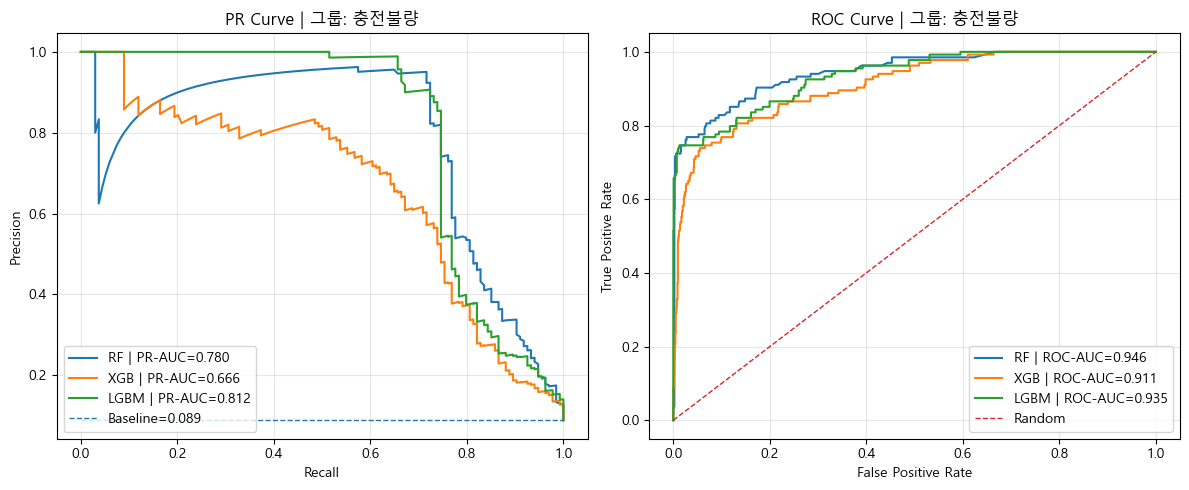


[PR/ROC] 기포/내부 | 불량 = 442


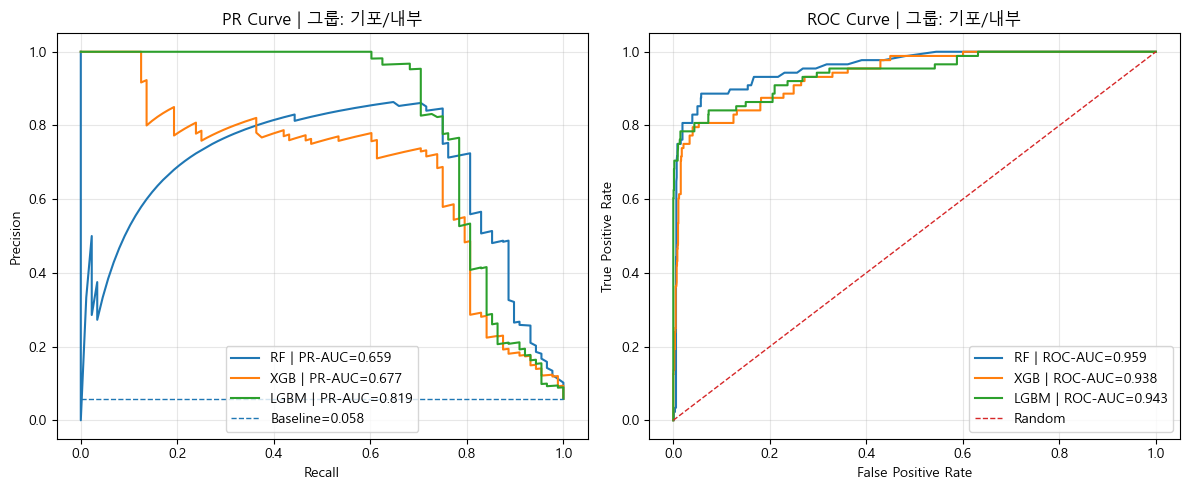


[PR/ROC] 표면손상 | 불량 = 500


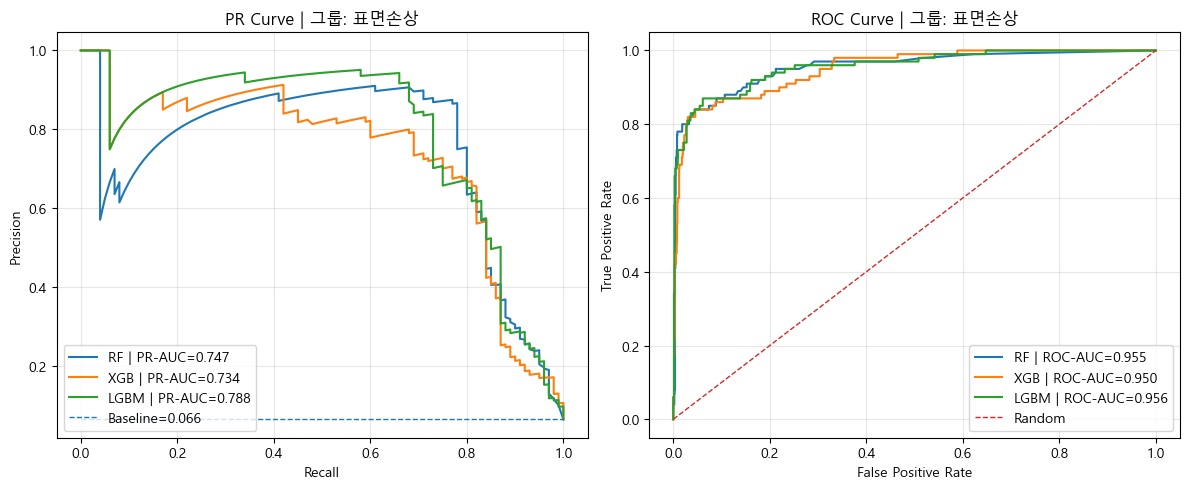


[PR/ROC] 기타 | 불량 = 191


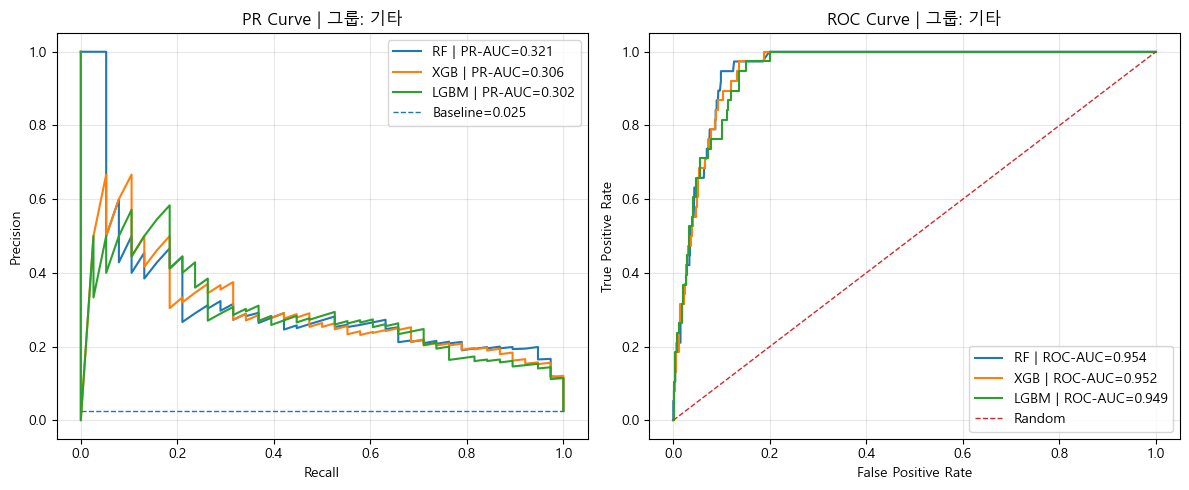


[PR/ROC 요약 테이블]


,group,model,PR_AUC(AP),ROC_AUC,test_pos,test_neg
0,기타,LGBM,0.302428,0.948802,38,1469
1,기타,RF,0.321493,0.953638,38,1469
2,기타,XGB,0.306371,0.951650,38,1469
3,기포/내부,LGBM,0.819371,0.943346,88,1419
4,기포/내부,RF,0.659199,0.959382,88,1419
5,기포/내부,XGB,0.677301,0.937884,88,1419
6,충전불량,LGBM,0.811948,0.935374,134,1373
7,충전불량,RF,0.779918,0.945622,134,1373
8,충전불량,XGB,0.666011,0.911361,134,1373
9,표면손상,LGBM,0.788434,0.956052,100,1407


In [22]:
# =========================
# (추가) PR Curve(PR-AUC) + ROC Curve(ROC-AUC) 그리기
# - 기존 모델/파라미터/SMOTE 로직은 그대로 사용(재학습 후 곡선만 시각화)
# - 참고 개념: PR Curve / ROC Curve (https://velog.io/@shihyunlim/ML-PR-Curve-ROC-curve)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mpl.rcParams["font.family"] = "Malgun Gothic"   # 맑은 고딕
mpl.rcParams["axes.unicode_minus"] = False      # 마이너스(-) 깨짐 방지

# 0) 필수 변수 체크
required = ["X", "Y_group"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(
        f"다음 변수가 없습니다: {missing}\n"
        f"이 셀은 X, Y_group 생성 이후(전처리/그룹 라벨 생성 이후)에 실행해야 합니다."
    )

def apply_smote_only_for_gita(gname, X_train, y_train):
    """
    기존 노트북 로직과 동일:
    - '기타' 그룹만 SMOTE 적용 (가능한 경우에만)
    """
    if gname != "기타":
        return X_train, y_train

    vc = y_train.value_counts()
    if len(vc) != 2:
        return X_train, y_train

    minority_n = vc.min()
    if minority_n < 2:
        return X_train, y_train

    k = min(5, minority_n - 1)
    smote = SMOTE(random_state=42, k_neighbors=k)
    return smote.fit_resample(X_train, y_train)

# 1) 결과 저장용
rows = []

# 2) 그룹별/모델별 PR/ROC 곡선 그리기
for gname in Y_group.columns:
    y = Y_group[gname]

    print("\n==============================")
    print(f"[PR/ROC] {gname} | 불량 = {int(y.sum())}")

    # train / test split (기존과 동일)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # (기타만) SMOTE
    X_train_use, y_train_use = apply_smote_only_for_gita(gname, X_train, y_train)

    # XGB scale_pos_weight (기존 코드와 동일 계산)
    pos = int((y_train_use == 1).sum())
    neg = int((y_train_use == 0).sum())
    spw = (neg / pos) if pos > 0 else 1

    models = {
        "RF": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ),
        "XGB": XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
            scale_pos_weight=spw
        ),
        "LGBM": LGBMClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
    }

    # (그룹 1개당) PR/ROC 한 장에 같이 그리기
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax_pr = axes[0]
    ax_roc = axes[1]

    for mname, model in models.items():
        model.fit(X_train_use, y_train_use)

        # 양성(불량=1) 확률
        proba = model.predict_proba(X_test)[:, 1]

        # PR
        prec, rec, _ = precision_recall_curve(y_test, proba)
        pr_auc = average_precision_score(y_test, proba)

        # ROC
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = roc_auc_score(y_test, proba)

        # plot
        ax_pr.plot(rec, prec, label=f"{mname} | PR-AUC={pr_auc:.3f}")
        ax_roc.plot(fpr, tpr, label=f"{mname} | ROC-AUC={roc_auc:.3f}")

        rows.append({
            "group": gname,
            "model": mname,
            "PR_AUC(AP)": pr_auc,
            "ROC_AUC": roc_auc,
            "test_pos": int((y_test == 1).sum()),
            "test_neg": int((y_test == 0).sum())
        })

    # PR baseline(양성비율) 표시
    base_rate = (y_test.sum() / len(y_test)) if len(y_test) > 0 else 0
    ax_pr.hlines(base_rate, 0, 1, linestyles="dashed", linewidth=1, label=f"Baseline={base_rate:.3f}")

    ax_pr.set_title(f"PR Curve | 그룹: {gname}")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.grid(True, alpha=0.3)
    ax_pr.legend(loc="best")

    # ROC 기준선
    ax_roc.plot([0, 1], [0, 1], linestyle="dashed", linewidth=1, label="Random")
    ax_roc.set_title(f"ROC Curve | 그룹: {gname}")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.grid(True, alpha=0.3)
    ax_roc.legend(loc="best")

    plt.tight_layout()
    plt.show()

# 3) 요약 테이블
prroc_df = pd.DataFrame(rows).sort_values(["group", "model"]).reset_index(drop=True)
print("\n[PR/ROC 요약 테이블]")
display(prroc_df)


[SHAP] target_group=충전불량 | model=LGBM


c:\Users\xcv54\workspace\develop_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\xcv54\workspace\develop_project\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


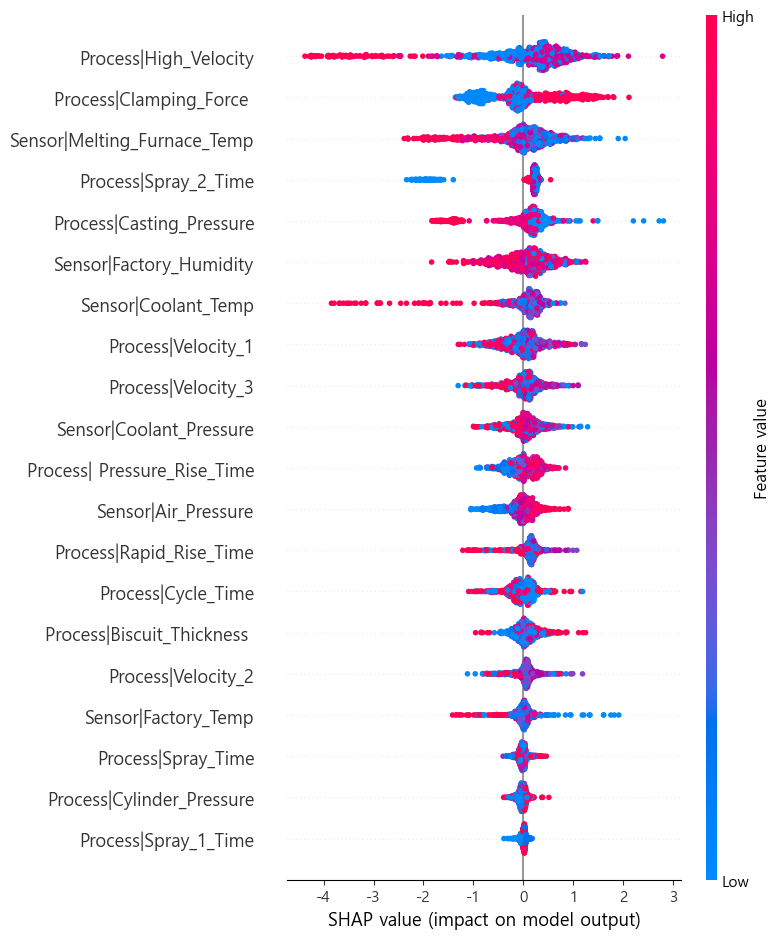

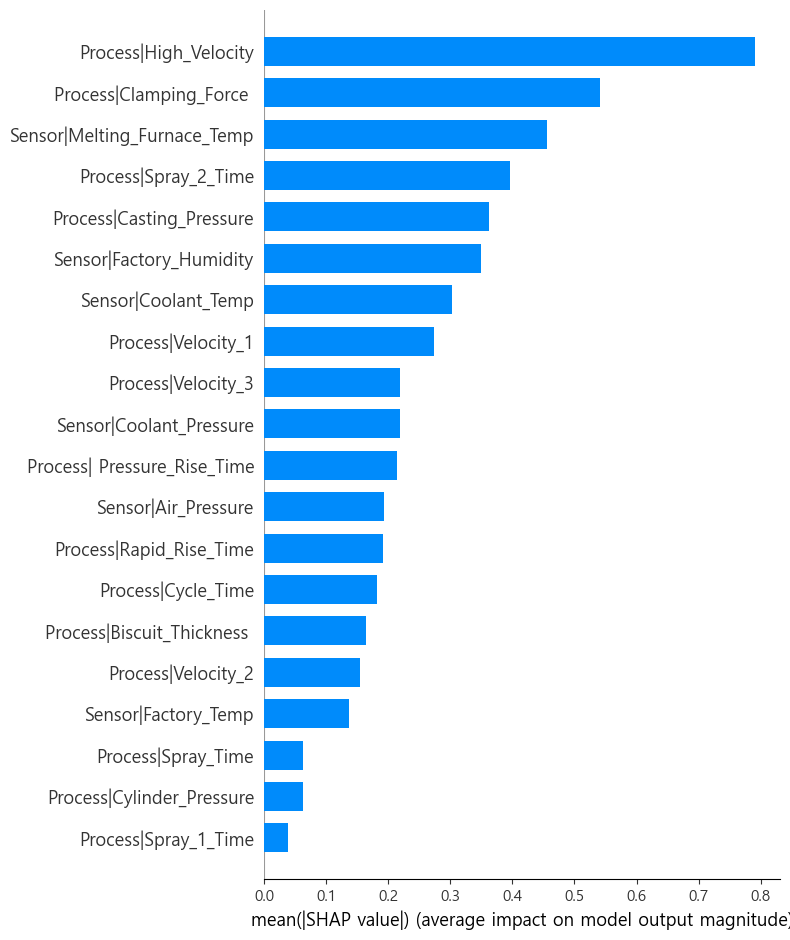

,feature,mean_abs_shap
4,Process|High_Velocity,0.791476
8,Process|Clamping_Force,0.540808
15,Sensor|Melting_Furnace_Temp,0.456044
14,Process|Spray_2_Time,0.396226
11,Process|Casting_Pressure,0.362971
20,Sensor|Factory_Humidity,0.348857
17,Sensor|Coolant_Temp,0.302801
1,Process|Velocity_1,0.273728
3,Process|Velocity_3,0.219535
18,Sensor|Coolant_Pressure,0.218545


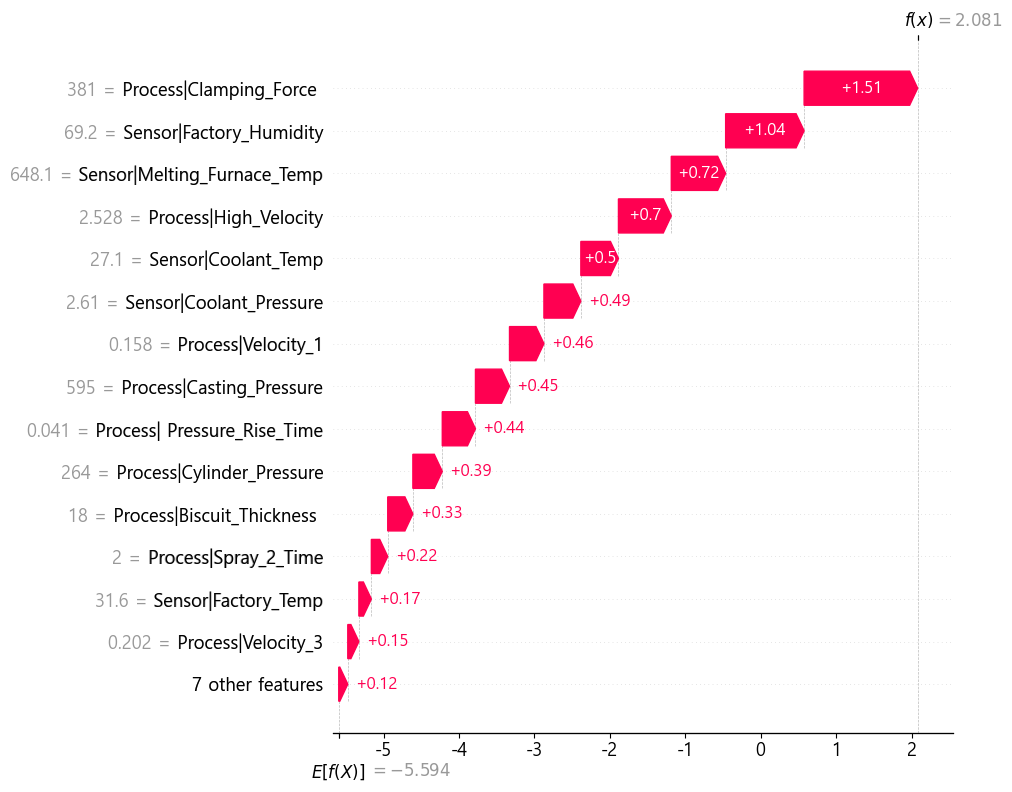

In [23]:
# =========================
# (추가) SHAP 해석: 트리 기반 모델(RF/XGB/LGBM)
# - threshold=0.6 고정 분류와는 별개로, 모델이 불량(1) 쪽으로 밀어주는 주요 변수를 해석하는 용도
# =========================

# 0) 설정
target_group = "충전불량"     # Y_group.columns 중 하나: ["충전불량","기포/내부","표면손상","기타"]
model_choice = "LGBM"     # "auto" / "RF" / "XGB" / "LGBM"
metric_for_auto = "recall"  # auto 선택 기준(기본: recall)
sample_size = 1000        # SHAP 계산에 사용할 X_test 샘플 수(속도 조절)

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from IPython.display import display

# 1) 유틸: 기존 노트북 로직과 동일하게 '기타'만 SMOTE 적용
def _apply_smote_only_for_gita(gname, X_train, y_train):
    if gname != "기타":
        return X_train, y_train

    vc = pd.Series(y_train).value_counts()
    if len(vc) == 2:
        minority_n = int(vc.min())
        if minority_n >= 2:
            k = min(5, minority_n - 1)
            smote = SMOTE(random_state=42, k_neighbors=k)
            X_train, y_train = smote.fit_resample(X_train, y_train)
    return X_train, y_train

# 2) 유틸: 이미 계산된 결과(rf_results/xgb_results/lgbm_results)가 있으면 auto로 가장 좋은 모델 선택
def _pick_model_name_auto(gname, metric="recall"):
    candidates = []
    for name, res in [("RF", globals().get("rf_results")),
                      ("XGB", globals().get("xgb_results")),
                      ("LGBM", globals().get("lgbm_results"))]:
        if isinstance(res, dict) and gname in res and isinstance(res[gname], dict) and metric in res[gname]:
            candidates.append((name, float(res[gname][metric])))

    if not candidates:
        # 결과 dict가 없거나 metric이 없으면 기본값 사용
        return "LGBM"

    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0][0]

# 3) 입력 검증
if "X" not in globals() or "Y_group" not in globals():
    raise NameError("X 또는 Y_group 변수가 없습니다. 전처리/라벨 생성 셀까지 실행 후 진행하세요.")

if target_group not in Y_group.columns:
    raise ValueError(f"target_group='{target_group}' 가 Y_group.columns에 없습니다. 가능한 값: {list(Y_group.columns)}")

# 4) 그룹 데이터 준비 + split
y = Y_group[target_group].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, y_train = _apply_smote_only_for_gita(target_group, X_train, y_train)

# 5) 모델 선택 및 학습
if model_choice == "auto":
    model_choice = _pick_model_name_auto(target_group, metric_for_auto)

print(f"[SHAP] target_group={target_group} | model={model_choice}")

if model_choice == "RF":
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)

elif model_choice == "XGB":
    # scale_pos_weight = (정상/불량) 비율
    vc = pd.Series(y_train).value_counts()
    spw = float(vc.get(0, 1) / max(vc.get(1, 1), 1))

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        scale_pos_weight=spw
    )
    model.fit(X_train, y_train)

elif model_choice == "LGBM":
    model = LGBMClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    model.fit(X_train, y_train)

else:
    raise ValueError("model_choice는 'auto' / 'RF' / 'XGB' / 'LGBM' 중 하나여야 합니다.")

# 6) SHAP 계산
try:
    import shap
except Exception as e:
    print("SHAP import 오류:", repr(e))
    print("해결 힌트:")
    print("  - pip install -U shap")
    print("  - numba/coverage 충돌 가능 시: pip install 'coverage<7'  또는 pip uninstall coverage")
    print("  - 그래도 안 되면, 현재 환경 패키지 버전을 확인해야 함")
    raise

# 속도 위해 X_test 일부만 사용
X_explain = X_test.copy()
if len(X_explain) > sample_size:
    X_explain = X_explain.sample(n=sample_size, random_state=42)

# TreeExplainer (트리 계열용)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_explain)

# === 반환 형태 통일: 항상 (n_samples, n_features) 되도록 정리 ===
if isinstance(shap_values, list):
    # binary일 때 [class0, class1] 구조 → 보통 불량(1) 클래스 기준 사용
    shap_values_1 = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    # Explanation 객체이거나 ndarray
    if hasattr(shap_values, "values"):
        shap_values_1 = shap_values.values
    else:
        shap_values_1 = shap_values

# (n_samples, n_features, n_classes) 같은 3차원인 경우 → 마지막 축에서 양성 클래스 선택
if shap_values_1.ndim == 3:
    # 보통 마지막 축이 클래스 축이므로, 양성 클래스로 가정하고 -1 인덱스 사용
    shap_values_1 = shap_values_1[:, :, -1]

# 여기까지 오면 shap_values_1.shape == (n_samples, n_features) 여야 함

# 7) 글로벌 해석: Summary(분포) + Bar(중요도)
# - 점 하나 = 샘플 1개
# - 오른쪽(+)일수록 불량(1) 쪽으로 밀어줌, 왼쪽(-)일수록 정상(0) 쪽으로 밀어줌
shap.summary_plot(shap_values_1, X_explain, show=True)                 # beeswarm
shap.summary_plot(shap_values_1, X_explain, plot_type="bar", show=True)

# 8) 숫자 테이블로도 확인: mean(|SHAP|) 상위 20개
#   (이 부분에서 이전에 2차원(mean_abs)이 되어 에러가 났던 것 → 위에서 2D로 정리해 둔 상태)
mean_abs = np.abs(shap_values_1).mean(axis=0)  # (n_features,)
shap_importance = (
    pd.DataFrame({"feature": X_explain.columns, "mean_abs_shap": mean_abs})
      .sort_values("mean_abs_shap", ascending=False)
)
display(shap_importance.head(20))

# 9) 로컬 해석: 특정 샘플 1개를 예로 waterfall
# - base_value(기본값)에서 시작해서, 각 변수의 SHAP이 더해져 최종 예측이 만들어짐
row_idx = 0

try:
    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        # binary인 경우 [class0, class1] 구조일 수 있으므로 양성 클래스 기준으로 선택
        base = base[1] if len(base) > 1 else base[0]

    exp = shap.Explanation(
        values=shap_values_1[row_idx],
        base_values=base,
        data=X_explain.iloc[row_idx].values,
        feature_names=X_explain.columns
    )
    shap.plots.waterfall(exp, max_display=15)
except Exception as e:
    print("waterfall plot 생성 중 오류:", repr(e))


In [ ]:
import numpy as np
import pandas as pd

# 변수명 확인
top_gname = globals().get("target_group", globals().get("top_gname", "UNKNOWN"))
sample_idx = int(globals().get("row_idx", globals().get("sample_idx", 0)))
shap_values_pos = globals().get("shap_values_pos", globals().get("shap_values_1"))

# 1. 예측 확률 계산 (sigmoid 적용)
logit = model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]  # 이미 확률
expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
shap_sum = np.asarray(shap_values_pos)[sample_idx].sum()
final_logit = expected_value + shap_sum
pred_probability = 1 / (1 + np.exp(-final_logit))  # sigmoid

print("[{} 예측 결과]".format(top_gname))
print(f"- 발생 확률: {pred_probability:.1%} ({pred_probability:.3f})")
print("")
print("[주요 원인 변수]")

# 2. SHAP 값 기준으로 상위 5개 양성 기여 변수 추출 (불량 확률을 올린 변수)
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "shap_value": np.asarray(shap_values_pos)[sample_idx]
})
shap_importance["abs_shap"] = np.abs(shap_importance["shap_value"])
top_positive = (
    shap_importance[shap_importance["shap_value"] > 0]
    .sort_values("shap_value", ascending=False)
    .head(5)
)

# 3. 각 변수에 대해 "정상 기준" 계산 (전체 데이터에서 정상 샘플(y=0)의 median 사용)
normal_samples = X[y == 0]
normal_means = normal_samples.median()

rank = 1
for _, row in top_positive.iterrows():
    feat = row["feature"]
    current_val = X_test.iloc[sample_idx][feat]
    normal_val = normal_means[feat]

    deviation = (current_val - normal_val) / normal_val * 100 if normal_val != 0 else 0
    risk = "위험" if deviation > 0 else "안전"  # 추측한 내용입니다(도메인 기준 미제공)

    print(f"{rank}. {str(feat).replace('Process|', '').replace('Sensor|', '').replace('_', ' ')}")
    print(f"   · 정상 기준: {normal_val:.2f}")
    print(f"   · 현재 값: {current_val:.2f}")
    print(f"   · 편차: {deviation:+.1f}% ({risk})")
    rank += 1


[충전불량 예측 결과]
- 발생 확률: 88.9% (0.889)

[주요 원인 변수]
1. Clamping Force 
   · 정상 기준: 258.00
   · 현재 값: 258.00
   · 편차: +0.0% (안전)
2. Factory Humidity
   · 정상 기준: 63.00
   · 현재 값: 61.40
   · 편차: -2.5% (안전)
3. Melting Furnace Temp
   · 정상 기준: 683.10
   · 현재 값: 691.80
   · 편차: +1.3% (위험)
4. High Velocity
   · 정상 기준: 2.16
   · 현재 값: 2.13
   · 편차: -1.4% (안전)
5. Coolant Temp
   · 정상 기준: 26.80
   · 현재 값: 26.50
   · 편차: -1.1% (안전)
